# Transfer learning, embeddings y explicabilidad — Enfermedades de mandioca

**Proyecto:** IC522 · Trabajo Final Integrador · **Alumno:** WLODECK, Fabricio Joaquín
**Datos:** 20 % del dataset filtrado (`datos\cambios 01 - no hojas\imagenes filtradas`, 26,304 imágenes)

Este notebook implementa:

1. **Ítems 1-2** — Transfer learning con dos backbones preentrenados (MobileNetV2 y EfficientNet-B7), cabeza propia, comparación por **macro-F1**. En timm 1.0.30, `efficientnet_b7` no publica pesos preentrenados, por lo que se usa `tf_efficientnet_b7` (misma arquitectura B7, pesos oficiales `ra_in1k`).
2. **Desbalance** — pesos de clase (`balanced`) en todos los entrenamientos.
3. **Splits** — subset 20 % → 80 % train+val (con val propio) / 20 % test; **test balanceado 100 por clase (500)**.
4. **Augmentación** — RandomCrop + VFlip + HFlip + RandomRotate(15°) vs. control sin augmentación (4 runs: E1-E4).
5. **Ítem 3** — Fine-tuning de MobileNetV2, con evaluación **antes y después** (E5).
6. **Ítem 4** — Clasificadores clásicos (RandomForest, SVM, XGBoost) y un MLP sobre embeddings del backbone.
7. **Ítem 6** — Explicabilidad con **LIME** sobre los dos modelos seleccionados automáticamente (menor cantidad de falsos negativos y menor latencia de inferencia) + verificación de sesgos espurios.
8. **Latencia** — Tiempo de inferencia (ms/imagen) de todos los modelos, deep y clásicos.

## Fase 0 — Entorno, semillas y configuración

In [1]:
import os, sys, json, time, random
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
from torchvision import transforms as T

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from IPython.display import display, Markdown

SMOKE = os.environ.get("SMOKE", "0") == "1"
TAG = "_smoke" if SMOKE else ""

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("torch:", torch.__version__, "| timm:", timm.__version__)
print("device:", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("modo SMOKE:", SMOKE)

D:\final_inteligencia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.14.0+cu126 | timm: 1.0.30
device: cuda - NVIDIA GeForce GTX 1660 SUPER
modo SMOKE: False


In [2]:
BASE = Path("D:/final_inteligencia")
DIR_IMG = BASE / "datos" / "cambios 01 - no hojas" / "imagenes filtradas"
DIR_LABELS = BASE / "datos" / "cambios 01 - no hojas" / "labels_filtrado.csv"
DIR_SPLIT = BASE / "datos" / "splits"
MANIFEST = DIR_SPLIT / "manifest_20pct_test100.csv"
DIR_MODEL = BASE / "modelos"
DIR_REPORT = BASE / "reportes"
DIR_SPLIT.mkdir(parents=True, exist_ok=True)
DIR_MODEL.mkdir(parents=True, exist_ok=True)

SEED = 42
FRAC_SUBSET, FRAC_TESTPOOL, FRAC_VAL = 0.20, 0.20, 0.20
MAX_TEST_PC = 100
CLASS_NAMES = ["cbb", "cbsd", "cgm", "cmd", "healthy"]
NUM_CLASSES = 5
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

CONFIG = {
    "E1": dict(backbone="mobilenetv2_100", size=224, aug=False, epochs=20, batch=32, lr=1e-3, patience=4),
    "E2": dict(backbone="mobilenetv2_100", size=224, aug=True,  epochs=20, batch=32, lr=1e-3, patience=4),
    "E3": dict(backbone="tf_efficientnet_b7.ra_in1k", size=600, aug=False, epochs=12, batch=4,  lr=1e-3, patience=4),
    "E4": dict(backbone="tf_efficientnet_b7.ra_in1k", size=600, aug=True,  epochs=12, batch=4,  lr=1e-3, patience=4),
}
FT_CFG = dict(epochs=6, lr=1e-4, patience=3, unfreeze=0.30)
LIME_SAMPLES = 500
LIME_ACIERTOS, LIME_ERRORES = 2, 2

if SMOKE:
    for k in CONFIG:
        CONFIG[k].update(epochs=1, patience=1)
    CONFIG["E1"].update(batch=8)
    CONFIG["E2"].update(batch=8)
    CONFIG["E3"].update(batch=2)
    CONFIG["E4"].update(batch=2)
    FT_CFG.update(epochs=1, patience=1)
    LIME_SAMPLES, LIME_ACIERTOS, LIME_ERRORES = 60, 1, 1

print(json.dumps({k: v for k, v in CONFIG.items()}, indent=1))
print("fine-tuning:", FT_CFG, "| LIME samples:", LIME_SAMPLES)

{
 "E1": {
  "backbone": "mobilenetv2_100",
  "size": 224,
  "aug": false,
  "epochs": 20,
  "batch": 32,
  "lr": 0.001,
  "patience": 4
 },
 "E2": {
  "backbone": "mobilenetv2_100",
  "size": 224,
  "aug": true,
  "epochs": 20,
  "batch": 32,
  "lr": 0.001,
  "patience": 4
 },
 "E3": {
  "backbone": "tf_efficientnet_b7.ra_in1k",
  "size": 600,
  "aug": false,
  "epochs": 12,
  "batch": 4,
  "lr": 0.001,
  "patience": 4
 },
 "E4": {
  "backbone": "tf_efficientnet_b7.ra_in1k",
  "size": 600,
  "aug": true,
  "epochs": 12,
  "batch": 4,
  "lr": 0.001,
  "patience": 4
 }
}
fine-tuning: {'epochs': 6, 'lr': 0.0001, 'patience': 3, 'unfreeze': 0.3} | LIME samples: 500


## Fase 1 — Datos: subset 20 %, train/val/test y test balanceado

Estratificación por **clase × source** (evita el sesgo de dominio 2019/2020, ver EDA §4.3), semilla 42:

1. subset = 20 % del dataset filtrado;
2. dentro del subset: 80 % train+val / 20 % test pool;
3. del train+val: 80 % train / 20 % val;
4. **test final balanceado**: 100 muestras por clase muestreadas del test pool; CBB solo tiene 60 en el pool, así que se completan 40 desde `out_subset` (mismo seed);
5. el resto del test pool queda **held-out** (no se entrena con él).

In [3]:
df_lab = pd.read_csv(DIR_LABELS)
df_lab["label_name"] = df_lab["label"].map(dict(enumerate(CLASS_NAMES)))
assert len(df_lab) == 26304 and df_lab["image_id"].is_unique

strata = df_lab["label"].astype(str) + "_" + df_lab["source"].astype(str)
subset_idx, _ = train_test_split(df_lab.index, train_size=FRAC_SUBSET, stratify=strata, random_state=SEED)

df_lab["split"] = "out_subset"
df_lab.loc[subset_idx, "split"] = "trainval"

sub = df_lab.loc[subset_idx]
strata_sub = sub["label"].astype(str) + "_" + sub["source"].astype(str)
trainval_idx, testpool_idx = train_test_split(sub.index, train_size=1 - FRAC_TESTPOOL,
                                              stratify=strata_sub, random_state=SEED)
df_lab.loc[testpool_idx, "split"] = "test_pool"

tv = df_lab.loc[trainval_idx]
strata_tv = tv["label"].astype(str) + "_" + tv["source"].astype(str)
train_idx, val_idx = train_test_split(tv.index, train_size=1 - FRAC_VAL,
                                      stratify=strata_tv, random_state=SEED)
df_lab.loc[train_idx, "split"] = "train"
df_lab.loc[val_idx, "split"] = "val"

pool = df_lab[df_lab["split"] == "test_pool"]
bal = pool.groupby("label", group_keys=False).apply(
    lambda g: g.sample(n=min(MAX_TEST_PC, len(g)), random_state=SEED), include_groups=False).index
df_lab.loc[df_lab.index.isin(bal), "split"] = "test"
df_lab.loc[df_lab["split"] == "test_pool", "split"] = "test_pool_rest"

cuenta_test = df_lab[df_lab.split == "test"].groupby("label").size().reindex(range(NUM_CLASSES), fill_value=0)
faltan = MAX_TEST_PC - cuenta_test
for lbl in faltan[faltan > 0].index:
    cand = df_lab[(df_lab.split == "out_subset") & (df_lab.label == lbl)]
    tomar = cand.sample(n=min(int(faltan[lbl]), len(cand)), random_state=SEED).index
    df_lab.loc[tomar, "split"] = "test"
    print(f"top-up test: clase {lbl} completa desde out_subset con {len(tomar)} imágenes")

top-up test: clase 0 completa desde out_subset con 40 imágenes


In [4]:
print("== conteo por split ==")
print(df_lab["split"].value_counts().to_string())

ct = pd.crosstab(df_lab["label_name"], df_lab["split"])[["train", "val", "test", "test_pool_rest", "out_subset"]]
print("\n== clase x split ==")
display(ct)

print("== fuente x split ==")
display(pd.crosstab(df_lab["source"], df_lab["split"]))

assert len(df_lab) == 26304
s_tr = set(df_lab[df_lab.split == "train"]["image_id"])
s_va = set(df_lab[df_lab.split == "val"]["image_id"])
s_te = set(df_lab[df_lab.split == "test"]["image_id"])
assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
tc = df_lab[df_lab.split == "test"]["label"].value_counts().sort_index()
assert (tc == MAX_TEST_PC).all()
assert set(df_lab["split"]) == {"train", "val", "test", "test_pool_rest", "out_subset"}
print("OK: sin leakage | activas =", int((df_lab.split != "out_subset").sum()),
      "| test balanceado total =", int(tc.sum()))

manifest = df_lab[["image_id", "label", "label_name", "source", "split"]].copy()
if SMOKE:
    keep = set()
    for sp, n in [("train", 8), ("val", 4), ("test", 4)]:
        keep |= set(manifest[manifest.split == sp].groupby("label", group_keys=False).head(n).index)
    manifest.loc[~manifest.index.isin(keep), "split"] = "out_subset"
    print("SMOKE: train/val/test reducidos a 8/4/4 por clase")
    display(manifest[manifest.split != "out_subset"].groupby(["split", "label"]).size().unstack(0))

== conteo por split ==
split
out_subset        21004
train              3366
val                 842
test_pool_rest      592
test                500

== clase x split ==


split,train,val,test,test_pool_rest,out_subset
label_name,,,,,
cbb,191,48,100,0,1153
cbsd,440,110,100,38,2756
cgm,387,96,100,20,2414
cmd,1979,495,100,518,12370
healthy,369,93,100,16,2311


== fuente x split ==


split,out_subset,test,test_pool_rest,train,val
source,,,,,
2019,3941,106,103,632,158
2020,17063,394,489,2734,684


OK: sin leakage | activas = 5300 | test balanceado total = 500


manifest guardado en D:\final_inteligencia\datos\splits\manifest_20pct_test100.csv


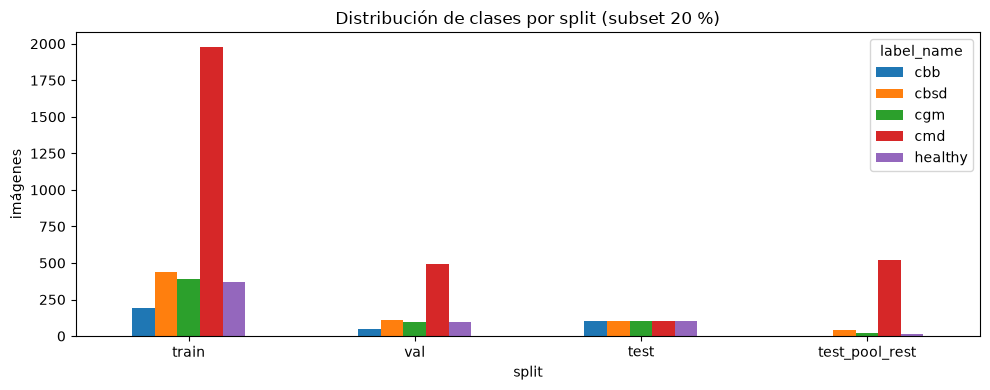

In [5]:
if not SMOKE:
    manifest.to_csv(MANIFEST, index=False)
    print("manifest guardado en", MANIFEST)
else:
    print("SMOKE: manifest NO se sobreescribe")

orden = ["train", "val", "test", "test_pool_rest", "out_subset"]
ct_plot = manifest[manifest.split != "out_subset"].groupby(["label_name", "split"]).size().unstack(0)[CLASS_NAMES]
ax = ct_plot.reindex(orden[:4]).plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_title("Distribución de clases por split (subset 20 %)")
ax.set_ylabel("imágenes"); ax.set_xlabel("split")
plt.tight_layout(); plt.show()

## Fase 2 — Infraestructura compartida

- **Transforms**: `Resize(256) + Crop(224)` (MobileNetV2) / `Resize(640) + Crop(600)` (EfficientNet-B7), sin deformar (EDA §4.4). Augmentación **solo** en train del brazo con aug: `RandomCrop`, `RandomVerticalFlip`, `RandomHorizontalFlip`, `RandomRotation(15°)`.
- **Pesos de clase** (`balanced`) calculados **solo sobre train**.
- **Cabeza**: GAP del backbone → Dropout(0.3) → Linear(5).
- **Selección**: mejor época por **macro-F1 de validación** + early stopping.

In [6]:
def build_transforms(size, aug):
    base = T.Resize(256 if size == 224 else 640, interpolation=T.InterpolationMode.BILINEAR)
    crop = T.RandomCrop(size) if aug else T.CenterCrop(size)
    ops = [base, crop]
    if aug:
        ops += [T.RandomVerticalFlip(0.5),
                T.RandomHorizontalFlip(0.5),
                T.RandomRotation(15)]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)

class MandiocaDataset(Dataset):
    def __init__(self, manifest_df, split, transform):
        self.df = manifest_df[manifest_df["split"] == split].reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(DIR_IMG / r["image_id"]).convert("RGB")
        return self.transform(img), int(r["label"])

tr_labels = manifest.loc[manifest.split == "train", "label"].values
pesos = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=tr_labels)
CLASS_W = torch.tensor(pesos, dtype=torch.float32, device=DEVICE)
print("pesos de clase:", {CLASS_NAMES[i]: round(float(p), 3) for i, p in enumerate(pesos)})

tf_demo = build_transforms(224, True)
ds_demo = MandiocaDataset(manifest, "train", tf_demo)
x0, y0 = ds_demo[0]
print("batch ejemplo:", tuple(x0.shape), "| clase:", CLASS_NAMES[y0])

pesos de clase: {'cbb': 3.525, 'cbsd': 1.53, 'cgm': 1.74, 'cmd': 0.34, 'healthy': 1.824}


batch ejemplo: (3, 224, 224) | clase: cmd


In [7]:
class Clf(nn.Module):
    def __init__(self, backbone_name):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.head = nn.Sequential(nn.Dropout(0.3),
                                  nn.Linear(self.backbone.num_features, NUM_CLASSES))
    def train(self, mode=True):
        super().train(mode)
        if mode:
            self.backbone.eval()
        return self
    def forward(self, x):
        return self.head(self.backbone(x))
    def featurizador(self, x):
        return self.backbone(x)

@torch.no_grad()
def evaluar(model, dataset, batch_size=64):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    ys, ps = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        ps.append(model(x).argmax(1).cpu().numpy())
        ys.append(y.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    per = f1_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    return dict(f1_macro=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
                f1_per_class=[float(v) for v in per],
                balanced_acc=float(balanced_accuracy_score(y_true, y_pred)),
                y_true=y_true.tolist(), y_pred=y_pred.tolist())

def eval_batch(cfg):
    if cfg["size"] == 224:
        return max(cfg["batch"], 32)
    return 8

In [8]:
def entrenar(exp_id, cfg):
    ckpt = DIR_MODEL / f"{exp_id}{TAG}.pth"
    res_path = DIR_MODEL / f"{exp_id}{TAG}_res.json"
    if ckpt.exists() and res_path.exists():
        res_cache = json.loads(res_path.read_text(encoding="utf-8"))
        n_test = int((manifest.split == "test").sum())
        if len(res_cache["test"]["y_true"]) == n_test:
            print(f"[cache] {exp_id} ya entrenado (test = {n_test} imgs)")
            return res_cache
        print(f"[cache] {exp_id}: test cambió ({len(res_cache['test']['y_true'])} -> {n_test}), "
              "re-evaluando SIN reentrenar")
        model = Clf(cfg["backbone"]).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        ds_te = MandiocaDataset(manifest, "test", build_transforms(cfg["size"], False))
        res_cache["test"] = evaluar(model, ds_te, batch_size=eval_batch(cfg))
        res_path.write_text(json.dumps(res_cache, indent=1), encoding="utf-8")
        print(f"{exp_id} test actualizado: testF1={res_cache['test']['f1_macro']:.4f}")
        return res_cache

    set_seed()
    ds_tr = MandiocaDataset(manifest, "train", build_transforms(cfg["size"], cfg["aug"]))
    ds_va = MandiocaDataset(manifest, "val", build_transforms(cfg["size"], False))
    ds_te = MandiocaDataset(manifest, "test", build_transforms(cfg["size"], False))
    dl_tr = DataLoader(ds_tr, batch_size=cfg["batch"], shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))

    model = Clf(cfg["backbone"]).to(DEVICE)
    for p in model.backbone.parameters():
        p.requires_grad = False
    model.eval()
    with torch.no_grad():
        f0 = model.backbone(torch.zeros(2, 3, cfg["size"], cfg["size"], device=DEVICE))
        sd0 = model.backbone.state_dict()
        n0 = sum(1 for v in sd0.values() if torch.is_tensor(v) and v.is_floating_point() and torch.isnan(v).any())
        print(f"{exp_id}: sanity feats_nan={torch.isnan(f0).any().item()} state_nan={n0}", flush=True)
    n_params = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg["lr"])
    crit = nn.CrossEntropyLoss(weight=CLASS_W)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    print(f"{exp_id}: train={len(ds_tr)} val={len(ds_va)} test={len(ds_te)} params={n_params:,} (entrenables={n_train:,})", flush=True)
    best_f1, best_state, wait, history, t0 = -1.0, None, 0, [], time.time()
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        ep_loss, n_seen, ep_t = 0.0, 0, time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                loss = crit(model(x), y)
            if not torch.isfinite(loss):
                if n_seen == 0 and ep == 1:
                    with torch.amp.autocast("cuda", enabled=use_amp):
                        f_dbg = model.backbone(x)
                        lg_dbg = model.head(f_dbg)
                    sd = model.backbone.state_dict()
                    nn_nan = sum(1 for v in sd.values() if torch.is_tensor(v) and v.is_floating_point() and torch.isnan(v).any())
                    neg_var = [k for k, v in sd.items() if k.endswith("running_var") and torch.is_tensor(v) and (v < 0).any().item()]
                    rb_nan = [k for k, v in sd.items() if "running" in k and torch.is_tensor(v) and torch.isnan(v).any()]
                    print(f"  [{exp_id}] DIAG x ok | feats nan={torch.isnan(f_dbg).any().item()} | "
                          f"backbone_state_nan={nn_nan} | running_nan={len(rb_nan)} {rb_nan[:3]} | "
                          f"neg_running_var={len(neg_var)} {neg_var[:3]} | "
                          f"loss={loss}", flush=True)
                print(f"  [{exp_id}] loss no finita en ep{ep}, batch descartado", flush=True)
                continue
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            ep_loss += float(loss) * len(y)
            n_seen += len(y)
        ev = evaluar(model, ds_va, batch_size=eval_batch(cfg))
        history.append(dict(epoch=ep, train_loss=round(ep_loss / n_seen, 4),
                            val_f1=round(ev["f1_macro"], 4),
                            epoch_time_s=round(time.time() - ep_t, 1)))
        print(f"  ep{ep}/{cfg['epochs']} loss={ep_loss / n_seen:.4f} valF1={ev['f1_macro']:.4f} ({history[-1]['epoch_time_s']}s)", flush=True)
        if ev["f1_macro"] > best_f1 + 1e-4:
            best_f1, wait = ev["f1_macro"], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg["patience"]:
                print("  early stopping")
                break

    torch.save(best_state, ckpt)
    model.load_state_dict(best_state)
    va = evaluar(model, ds_va, batch_size=eval_batch(cfg))
    te = evaluar(model, ds_te, batch_size=eval_batch(cfg))
    res = dict(id=exp_id, metodo="transfer learning (cabeza)", backbone=cfg["backbone"],
               size=cfg["size"], aug=cfg["aug"], epochs_run=len(history),
               params=n_params, tiempo_total_s=round(time.time() - t0, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 1),
               val=va, test=te, history=history)
    res_path.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"{exp_id} listo: valF1={va['f1_macro']:.4f} testF1={te['f1_macro']:.4f} ({res['tiempo_total_s']}s)")
    return res

RESULTADOS = {}

## Fase 3 — Experimentos de transfer learning (E1-E4)

| ID | Backbone | Input | Augmentación |
|---|---|---|---|
| E1 | MobileNetV2 | 224 | no |
| E2 | MobileNetV2 | 224 | **sí** (RandomCrop+VFlip+HFlip+Rotate) |
| E3 | EfficientNet-B7 | 600 | no |
| E4 | EfficientNet-B7 | 600 | **sí** |

In [9]:
RESULTADOS["E1"] = entrenar("E1", CONFIG["E1"])

[cache] E1 ya entrenado (test = 500 imgs)


In [10]:
RESULTADOS["E2"] = entrenar("E2", CONFIG["E2"])

[cache] E2 ya entrenado (test = 500 imgs)


In [11]:
RESULTADOS["E3"] = entrenar("E3", CONFIG["E3"])

[cache] E3 ya entrenado (test = 500 imgs)


In [12]:
RESULTADOS["E4"] = entrenar("E4", CONFIG["E4"])

[cache] E4 ya entrenado (test = 500 imgs)


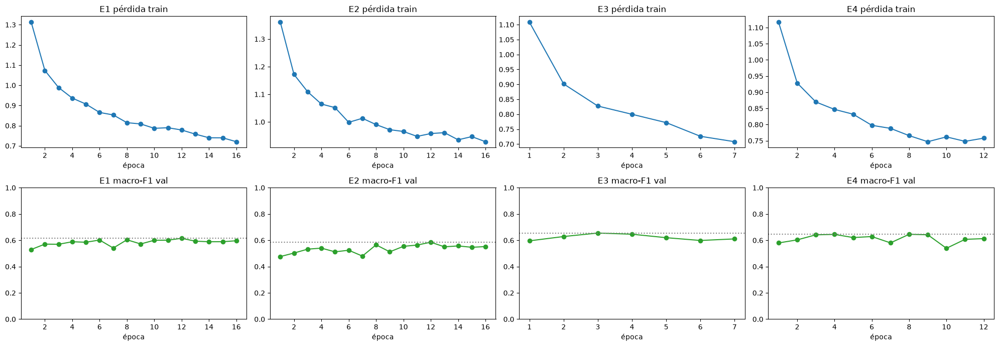

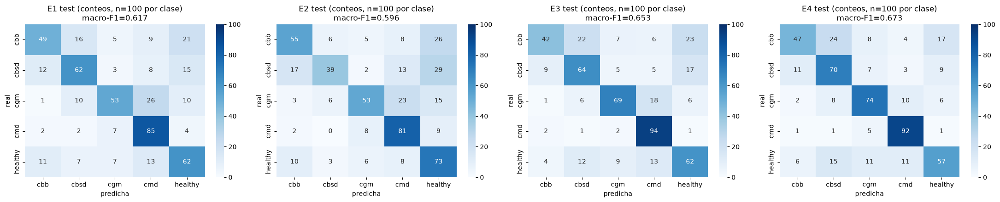

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
for j, eid in enumerate(["E1", "E2", "E3", "E4"]):
    h = pd.DataFrame(RESULTADOS[eid]["history"])
    axes[0, j].plot(h["epoch"], h["train_loss"], marker="o")
    axes[0, j].set_title(f"{eid} pérdida train"); axes[0, j].set_xlabel("época")
    axes[1, j].plot(h["epoch"], h["val_f1"], marker="o", color="tab:green")
    axes[1, j].axhline(RESULTADOS[eid]["val"]["f1_macro"], ls=":", color="gray")
    axes[1, j].set_title(f"{eid} macro-F1 val"); axes[1, j].set_xlabel("época")
    axes[1, j].set_ylim(0, 1)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for j, eid in enumerate(["E1", "E2", "E3", "E4"]):
    te = RESULTADOS[eid]["test"]
    cm = confusion_matrix(te["y_true"], te["y_pred"], labels=np.arange(NUM_CLASSES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", vmin=0, vmax=100, ax=axes[j],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[j].set_title(f"{eid} test (conteos, n=100 por clase)\nmacro-F1={te['f1_macro']:.3f}")
    axes[j].set_xlabel("predicha"); axes[j].set_ylabel("real")
plt.tight_layout(); plt.show()

In [14]:
filas = []
for eid in ["E1", "E2", "E3", "E4"]:
    r = RESULTADOS[eid]
    filas.append(dict(ID=eid, Metodo="TL cabeza", Backbone=r["backbone"], Input=r["size"],
                      Aug="si" if r["aug"] else "no", Epocas=r["epochs_run"],
                      F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                      BalAcc=r["test"]["balanced_acc"], Params=r["params"],
                      s_epoc=r["tiempo_ep_s"]))
tabla_e = pd.DataFrame(filas)
display(tabla_e.round(4))

,ID,Metodo,Backbone,Input,Aug,Epocas,F1_val,F1_test,BalAcc,Params,s_epoc
0,E1,TL cabeza,mobilenetv2_100,224,no,16,0.6152,0.6171,0.622,2230277,65.9
1,E2,TL cabeza,mobilenetv2_100,224,si,16,0.5854,0.5957,0.602,2230277,57.2
2,E3,TL cabeza,tf_efficientnet_b7.ra_in1k,600,no,7,0.6551,0.6529,0.662,63799765,626.9
3,E4,TL cabeza,tf_efficientnet_b7.ra_in1k,600,si,12,0.6455,0.6727,0.680,63799765,650.1


## Fase 4 — Fine-tuning de MobileNetV2 (E5): evaluación antes / después

- Se elige el mejor de E1/E2 por macro-F1 de validación → **checkpoint A = "antes"**.
- Se descongelan los **últimos ~30 % de parámetros** del backbone (head siempre entrenable), Adam `lr=1e-4`, ≤6 épocas, early stopping.
- **Checkpoint B = "después"**; se evalúa A y B con la **misma función** sobre val y test balanceado.

In [15]:
mv2_ids = ["E1", "E2"]
mejor_mv2 = max(mv2_ids, key=lambda i: RESULTADOS[i]["val"]["f1_macro"])
print("mejor config MobileNetV2:", mejor_mv2,
      "| val F1 =", round(RESULTADOS[mejor_mv2]["val"]["f1_macro"], 4))

def fine_tuning(exp_antes):
    ckpt_b = DIR_MODEL / f"E5{TAG}.pth"
    res_b = DIR_MODEL / f"E5{TAG}_res.json"
    if ckpt_b.exists() and res_b.exists():
        res_cache = json.loads(res_b.read_text(encoding="utf-8"))
        n_test = int((manifest.split == "test").sum())
        if len(res_cache["test"]["y_true"]) == n_test:
            print("[cache] E5 ya entrenado (test = %d imgs)" % n_test)
            return res_cache
        print(f"[cache] E5: test cambió ({len(res_cache['test']['y_true'])} -> {n_test}), "
              "re-evaluando SIN reentrenar")
        cfg = CONFIG[exp_antes]
        model = Clf(cfg["backbone"]).to(DEVICE)
        model.load_state_dict(torch.load(ckpt_b, map_location=DEVICE))
        ds_te = MandiocaDataset(manifest, "test", build_transforms(cfg["size"], False))
        res_cache["test"] = evaluar(model, ds_te, batch_size=eval_batch(cfg))
        res_b.write_text(json.dumps(res_cache, indent=1), encoding="utf-8")
        print(f"E5 test actualizado: testF1={res_cache['test']['f1_macro']:.4f}")
        return res_cache

    set_seed()
    cfg = CONFIG[exp_antes]
    model = Clf(cfg["backbone"]).to(DEVICE)
    model.load_state_dict(torch.load(DIR_MODEL / f"{exp_antes}{TAG}.pth", map_location=DEVICE))

    for p in model.parameters():
        p.requires_grad = False
    named = dict(model.backbone.named_parameters())
    nom = list(named.keys())
    k = int(len(nom) * FT_CFG["unfreeze"])
    for n in nom[len(nom) - k:]:
        named[n].requires_grad = True
    n_ent = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot = sum(p.numel() for p in model.parameters())
    print(f"descongelados {k}/{len(nom)} tensores backbone -> {n_ent:,} params entrenables de {n_tot:,}")

    ds_tr = MandiocaDataset(manifest, "train", build_transforms(cfg["size"], cfg["aug"]))
    ds_va = MandiocaDataset(manifest, "val", build_transforms(cfg["size"], False))
    ds_te = MandiocaDataset(manifest, "test", build_transforms(cfg["size"], False))
    dl_tr = DataLoader(ds_tr, batch_size=cfg["batch"], shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))

    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=FT_CFG["lr"])
    crit = nn.CrossEntropyLoss(weight=CLASS_W)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_f1, best_state, wait, history, t0 = -1.0, None, 0, [], time.time()
    for ep in range(1, FT_CFG["epochs"] + 1):
        model.train()
        ep_loss, n_seen, ep_t = 0.0, 0, time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                loss = crit(model(x), y)
            if not torch.isfinite(loss):
                print("  [E5] loss no finita, batch descartado", flush=True)
                continue
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            ep_loss += float(loss) * len(y)
            n_seen += len(y)
        ev = evaluar(model, ds_va, batch_size=eval_batch(cfg))
        history.append(dict(epoch=ep, train_loss=round(ep_loss / n_seen, 4),
                            val_f1=round(ev["f1_macro"], 4),
                            epoch_time_s=round(time.time() - ep_t, 1)))
        print(f"  FT ep{ep}/{FT_CFG['epochs']} loss={ep_loss / n_seen:.4f} valF1={ev['f1_macro']:.4f} ({history[-1]['epoch_time_s']}s)", flush=True)
        if ev["f1_macro"] > best_f1 + 1e-4:
            best_f1, wait = ev["f1_macro"], 0
            best_state = {kk: v.detach().cpu().clone() for kk, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= FT_CFG["patience"]:
                print("  early stopping")
                break

    torch.save(best_state, ckpt_b)
    model.load_state_dict(best_state)
    va = evaluar(model, ds_va, batch_size=eval_batch(cfg))
    te = evaluar(model, ds_te, batch_size=eval_batch(cfg))
    res = dict(id="E5", metodo="fine-tuning MV2 (30 % backbone)", backbone=cfg["backbone"],
               size=cfg["size"], aug=cfg["aug"], epochs_run=len(history),
               params=n_ent, tiempo_total_s=round(time.time() - t0, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 1),
               antes=exp_antes, val=va, test=te, history=history)
    res_b.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"E5 listo: valF1={va['f1_macro']:.4f} testF1={te['f1_macro']:.4f}")
    return res

RESULTADOS["E5"] = fine_tuning(mejor_mv2)
print("antes:", RESULTADOS[mejor_mv2]["val"]["f1_macro"], "| despues:", RESULTADOS["E5"]["val"]["f1_macro"])

mejor config MobileNetV2: E1 | val F1 = 0.6152
[cache] E5 ya entrenado (test = 500 imgs)
antes: 0.615210325811482 | despues: 0.6875158585483238


,Estado,Back,F1_val,F1_test,f1_cbb,f1_cbsd,f1_cgm,f1_cmd,f1_healthy,BalAcc
0,E1 (antes FT),cabeza congelada,0.6152,0.6171,0.5600,0.6294,0.6057,0.7054,0.5849,0.622
1,E5 (despues FT),fine-tuning 30 %,0.6875,0.6706,0.6286,0.7317,0.6550,0.7294,0.6082,0.676


delta test macro-F1: 0.0535


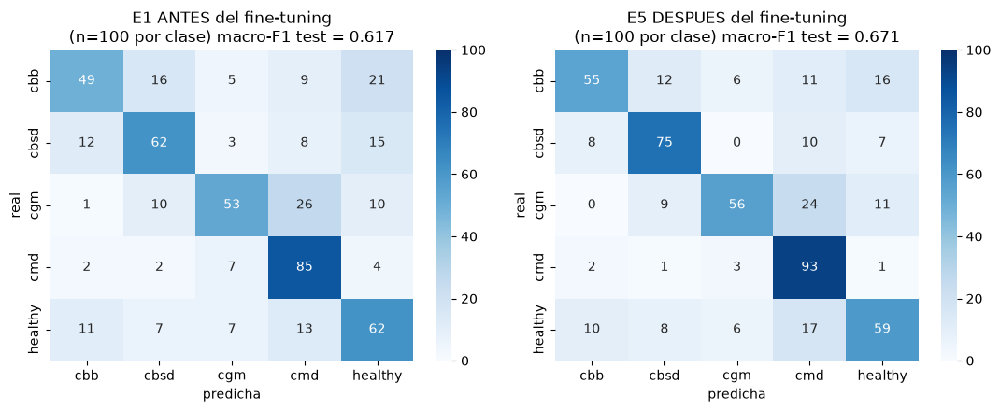

In [16]:
res_antes, res_des = RESULTADOS[mejor_mv2], RESULTADOS["E5"]
filas = []
for etiqueta, estado, r in [(f"{mejor_mv2} (antes FT)", "cabeza congelada", res_antes),
                            ("E5 (despues FT)", "fine-tuning 30 %", res_des)]:
    filas.append(dict(Estado=etiqueta, Back=estado, F1_val=r["val"]["f1_macro"],
                      F1_test=r["test"]["f1_macro"],
                      **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)},
                      BalAcc=r["test"]["balanced_acc"]))
tabla_ab = pd.DataFrame(filas)
display(tabla_ab.round(4))
print("delta test macro-F1:", round(res_des["test"]["f1_macro"] - res_antes["test"]["f1_macro"], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (titulo, r) in zip(axes, [(f"{mejor_mv2} ANTES del fine-tuning", res_antes),
                                  ("E5 DESPUES del fine-tuning", res_des)]):
    te = r["test"]
    cm = confusion_matrix(te["y_true"], te["y_pred"], labels=np.arange(NUM_CLASSES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", vmin=0, vmax=100, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{titulo}\n(n=100 por clase) macro-F1 test = {te['f1_macro']:.3f}")
    ax.set_xlabel("predicha"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()

## Fase 5 — Ítem 4: embeddings + clasificadores clásicos (y una red sobre embeddings)

- Features = salida del **GAP del backbone ImageNet congelado** (sin head), mismas transformaciones de evaluación; se cachean en `.npz`.
- Clasificadores: **RandomForest** (`class_weight=balanced_subsample`), **SVM RBF** (grid chico C/γ sobre val, `class_weight=balanced`), **XGBoost** (`sample_weight` balanceado) y un **MLP end-to-end** con pesos de clase.
- Se comparan contra las redes end-to-end E1-E5 con la misma métrica y el mismo test balanceado.

In [17]:
@torch.no_grad()
def extraer_embeddings(backbone_name, size, split):
    ds = MandiocaDataset(manifest, split, build_transforms(size, False))
    cache = DIR_MODEL / f"emb_{backbone_name}_{split}{TAG}.npz"
    if cache.exists():
        d = np.load(cache)
        if d["X"].shape[0] == len(ds):
            print(f"[cache] emb {backbone_name} {split}: {d['X'].shape}")
            return d["X"], d["y"]
        print(f"[cache] emb {backbone_name} {split}: {d['X'].shape[0]} != {len(ds)} -> re-extrayendo")
    model = Clf(backbone_name).to(DEVICE)
    model.eval()
    dl = DataLoader(ds, batch_size=8 if size == 600 else 64, shuffle=False, num_workers=0)
    feats, labs = [], []
    for x, y in dl:
        f = model.featurizador(x.to(DEVICE)).float().cpu().numpy()
        feats.append(f); labs.append(y.numpy())
    X = np.concatenate(feats).astype(np.float32)
    y = np.concatenate(labs)
    np.savez_compressed(cache, X=X, y=y)
    print(f"emb {backbone_name} {split}: {X.shape}")
    return X, y

EMB = {}
for bb_name, bb_size in [("mobilenetv2_100", 224), ("tf_efficientnet_b7.ra_in1k", 600)]:
    EMB[bb_name] = {}
    for sp in ["train", "val", "test"]:
        X, y = extraer_embeddings(bb_name, bb_size, sp)
        EMB[bb_name][sp] = (X, y)
    assert EMB[bb_name]["train"][1].shape[0] == int((manifest.split == "train").sum())

[cache] emb mobilenetv2_100 train: (3366, 1280)


[cache] emb mobilenetv2_100 val: (842, 1280)
[cache] emb mobilenetv2_100 test: (500, 1280)


[cache] emb tf_efficientnet_b7.ra_in1k train: (3366, 2560)


[cache] emb tf_efficientnet_b7.ra_in1k val: (842, 2560)


[cache] emb tf_efficientnet_b7.ra_in1k test: (500, 2560)


In [18]:
def bb_key(name):
    return "mobilenetv2" if name.startswith("mobilenet") else "efficientnet"

def metricas_sklearn(y_true, y_pred):
    per = f1_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    return dict(f1_macro=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
                f1_per_class=[float(v) for v in per],
                balanced_acc=float(balanced_accuracy_score(y_true, y_pred)),
                y_true=np.asarray(y_true).tolist(), y_pred=np.asarray(y_pred).tolist())

def registrar_ml(exp_id, metodo, backbone, extra, val_m, test_m, params, t_s):
    res = dict(id=exp_id, metodo=metodo, backbone=backbone, size=None, aug=None,
               epochs_run=None, params=params, tiempo_total_s=round(t_s, 1),
               tiempo_ep_s=None, extra=extra, val=val_m, test=test_m)
    (DIR_MODEL / f"{exp_id}{TAG}_res.json").write_text(json.dumps(res, indent=1), encoding="utf-8")
    return res

def pesos_balanceados(y):
    n = len(y); k = NUM_CLASSES
    counts = np.bincount(np.asarray(y), minlength=k)
    return n / (k * counts[y])


CLFS = {}

In [19]:
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    if not warnings.filters:
        warnings.simplefilter("default")
    warnings.filterwarnings("ignore", message=r"`sklearn\.utils\.parallel\.delayed`")
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    t0 = time.time()
    clf = RandomForestClassifier(n_estimators=500, class_weight="balanced_subsample",
                                 random_state=SEED, n_jobs=-1)
    clf.fit(Xtr, ytr)
    CLFS[(bb_key(bb_name), "RF")] = (clf, None)
    res = registrar_ml(f"E6_{bb_key(bb_name)}", "RandomForest", bb_name, "n=500",
                       metricas_sklearn(yv, clf.predict(Xv)),
                       metricas_sklearn(yt, clf.predict(Xt)),
                       500, time.time() - t0)
    print(bb_name, "RF test F1 =", round(res["test"]["f1_macro"], 4))

mobilenetv2_100 RF test F1 = 0.2917


tf_efficientnet_b7.ra_in1k RF test F1 = 0.3506


In [20]:
mejores = {}
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xv_s, Xt_s = sc.transform(Xtr), sc.transform(Xv), sc.transform(Xt)
    mejor = None
    t0 = time.time()
    for C in [1, 10]:
        for gamma in ["scale", 1e-3]:
            clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=SEED)
            clf.fit(Xtr_s, ytr)
            f1v = f1_score(yv, clf.predict(Xv_s), average="macro", zero_division=0)
            print(f"  {bb_name} SVM C={C} gamma={gamma} valF1={f1v:.4f}")
            if mejor is None or f1v > mejor[0]:
                mejor = (f1v, C, gamma, clf)
    _, C_best, gamma_best, clf = mejor
    CLFS[(bb_key(bb_name), "SVM")] = (clf, sc)
    res = registrar_ml(f"E7_{bb_key(bb_name)}", "SVM RBF", bb_name, f"C={C_best}, gamma={gamma_best}",
                       metricas_sklearn(yv, clf.predict(Xv_s)),
                       metricas_sklearn(yt, clf.predict(Xt_s)),
                       len(clf.support_), time.time() - t0)
    print(bb_name, "SVM test F1 =", round(res["test"]["f1_macro"], 4))

  mobilenetv2_100 SVM C=1 gamma=scale valF1=0.6204


  mobilenetv2_100 SVM C=1 gamma=0.001 valF1=0.6096


  mobilenetv2_100 SVM C=10 gamma=scale valF1=0.6063


  mobilenetv2_100 SVM C=10 gamma=0.001 valF1=0.5842


mobilenetv2_100 SVM test F1 = 0.5622


  tf_efficientnet_b7.ra_in1k SVM C=1 gamma=scale valF1=0.6194


  tf_efficientnet_b7.ra_in1k SVM C=1 gamma=0.001 valF1=0.5667


  tf_efficientnet_b7.ra_in1k SVM C=10 gamma=scale valF1=0.6370


  tf_efficientnet_b7.ra_in1k SVM C=10 gamma=0.001 valF1=0.5449


tf_efficientnet_b7.ra_in1k SVM test F1 = 0.608


In [21]:
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    t0 = time.time()
    import xgboost as xgb
    clf = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                            objective="multi:softprob", num_class=NUM_CLASSES,
                            eval_metric="mlogloss", tree_method="hist",
                            random_state=SEED, n_jobs=-1, reg_lambda=1.0)
    clf.fit(Xtr, ytr, sample_weight=pesos_balanceados(ytr),
            eval_set=[(Xv, yv)], verbose=False)
    CLFS[(bb_key(bb_name), "XGB")] = (clf, None)
    res = registrar_ml(f"E8_{bb_key(bb_name)}", "XGBoost", bb_name, "n=300, d=6, lr=0.1",
                       metricas_sklearn(yv, clf.predict(Xv)),
                       metricas_sklearn(yt, clf.predict(Xt)),
                       300, time.time() - t0)
    print(bb_name, "XGB test F1 =", round(res["test"]["f1_macro"], 4))

mobilenetv2_100 XGB test F1 = 0.5347


tf_efficientnet_b7.ra_in1k XGB test F1 = 0.589


In [22]:
def entrenar_mlp(Xtr, ytr, Xv, yv, Xt, yt, epochs=150, batch=256):
    set_seed()
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xv_s, Xt_s = sc.transform(Xtr), sc.transform(Xv), sc.transform(Xt)
    F = Xtr_s.shape[1]
    model = nn.Sequential(nn.Linear(F, 256), nn.ReLU(), nn.Dropout(0.3),
                          nn.Linear(256, NUM_CLASSES)).to(DEVICE)
    counts = np.bincount(np.asarray(ytr), minlength=NUM_CLASSES).astype(np.float64)
    w = torch.tensor(len(ytr) / (NUM_CLASSES * counts), dtype=torch.float32, device=DEVICE)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xv_t = torch.tensor(Xv_s, dtype=torch.float32, device=DEVICE)
    yv_t = torch.tensor(yv, dtype=torch.long, device=DEVICE)
    n = len(Xtr_t)
    best_f1, best_state, wait, t0 = -1.0, None, 0, time.time()
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            xb, yb = Xtr_t[idx].to(DEVICE), ytr_t[idx].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            f1v = f1_score(yv_t.cpu().numpy(), model(Xv_t).argmax(1).cpu().numpy(),
                           average="macro", zero_division=0)
        if f1v > best_f1 + 1e-4:
            best_f1, wait = f1v, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= 15:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_v = model(Xv_t).argmax(1).cpu().numpy()
        pred_t = model(torch.tensor(Xt_s, dtype=torch.float32, device=DEVICE)).argmax(1).cpu().numpy()
    return pred_v, pred_t, model, time.time() - t0, sc

for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    pred_v, pred_t, model_mlp, t_s, sc_mlp = entrenar_mlp(Xtr, ytr, Xv, yv, Xt, yt,
                                                  epochs=2 if SMOKE else 150)
    CLFS[(bb_key(bb_name), "MLP")] = (model_mlp, sc_mlp)
    n_par = sum(p.numel() for p in model_mlp.parameters())
    res = registrar_ml(f"E9_{bb_key(bb_name)}", "MLP (red sobre embeddings)", bb_name,
                       "256 ocultas", metricas_sklearn(yv, pred_v),
                       metricas_sklearn(yt, pred_t), n_par, t_s)
    print(bb_name, "MLP test F1 =", round(res["test"]["f1_macro"], 4))

mobilenetv2_100 MLP test F1 = 0.5731


tf_efficientnet_b7.ra_in1k MLP test F1 = 0.6224


## Fase 6 — Latencia de inferencia (ms/imagen)

Se mide el **tiempo de predicción** de todos los modelos:

- **Deep (E1-E5)**: forward completo desde píxeles, en `batch=1` (decisión sobre una foto suelta) y
  `batch=32` (`batch=8` para EfficientNet-B7 @600, por memoria en la GPU).
- **Clásicos (E6-E9)**: extracción del embedding (forward del backbone, batch=1) + `predict()` del
  clasificador sobre ese vector.

Se guardan en `reportes\02_latencia_deep.csv` y `reportes\02_latencia_clasicos.csv`.


In [23]:
@torch.no_grad()
def medir_latencia_deep(model, size, batch=1, n_iter=100, warmup=15):
    model.eval()
    x = torch.randn(batch, 3, size, size, device=DEVICE)
    for _ in range(warmup):
        model(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        model(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_iter * 1000.0 / batch


n_iter_lat = 20 if SMOKE else 100
filas_lat = []
for eid in ["E1", "E2", "E3", "E4", "E5"]:
    r = RESULTADOS[eid]
    modelo = Clf(r["backbone"]).to(DEVICE)
    modelo.load_state_dict(torch.load(DIR_MODEL / f"{eid}{TAG}.pth", map_location=DEVICE))
    for b in ([1, 8] if r["size"] == 600 else [1, 32]):
        ms = medir_latencia_deep(modelo, r["size"], batch=b,
                                 n_iter=max(10, n_iter_lat // 2) if r["size"] == 600 else n_iter_lat)
        filas_lat.append(dict(modelo=eid, backbone=r["backbone"], size=r["size"],
                              batch=b, ms_por_imagen=round(ms, 3)))
        print(f"{eid} batch={b}: {ms:.3f} ms/imagen")
    del modelo
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

tabla_latencia_deep = pd.DataFrame(filas_lat)
display(tabla_latencia_deep)
if not SMOKE:
    tabla_latencia_deep.to_csv(DIR_REPORT / "02_latencia_deep.csv", index=False)
    print("CSV:", DIR_REPORT / "02_latencia_deep.csv")


E1 batch=1: 20.239 ms/imagen


E1 batch=32: 0.893 ms/imagen


E2 batch=1: 16.958 ms/imagen


E2 batch=32: 0.890 ms/imagen


E3 batch=1: 83.022 ms/imagen


...

E4 batch=8: 65.035 ms/imagen


E5 batch=1: 14.806 ms/imagen


E5 batch=32: 0.895 ms/imagen


,modelo,backbone,size,batch,ms_por_imagen
0,E1,mobilenetv2_100,224,1,20.239
1,E1,mobilenetv2_100,224,32,0.893
2,E2,mobilenetv2_100,224,1,16.958
3,E2,mobilenetv2_100,224,32,0.890
4,E3,tf_efficientnet_b7.ra_in1k,600,1,83.022
5,E3,tf_efficientnet_b7.ra_in1k,600,8,64.706
6,E4,tf_efficientnet_b7.ra_in1k,600,1,73.715
7,E4,tf_efficientnet_b7.ra_in1k,600,8,65.035
8,E5,mobilenetv2_100,224,1,14.806
9,E5,mobilenetv2_100,224,32,0.895


CSV: D:\final_inteligencia\reportes\02_latencia_deep.csv


In [24]:
if not warnings.filters:
    warnings.simplefilter("default")
warnings.filterwarnings("ignore", message=r"`sklearn\.utils\.parallel\.delayed`")


def medir_predict(clf, sc, X1, n_iter=200):
    X = sc.transform(X1) if sc is not None else X1
    if isinstance(clf, nn.Module):
        clf.eval()
        Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            for _ in range(10):
                clf(Xt)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(n_iter):
                clf(Xt)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
        return (time.perf_counter() - t0) / n_iter * 1000.0
    for _ in range(10):
        clf.predict(X)
    t0 = time.perf_counter()
    for _ in range(n_iter):
        clf.predict(X)
    return (time.perf_counter() - t0) / n_iter * 1000.0


@torch.no_grad()
def medir_embedding_backbone(backbone_name, size, n_iter=20):
    model = Clf(backbone_name).to(DEVICE)
    model.eval()
    x = torch.randn(1, 3, size, size, device=DEVICE)
    for _ in range(5):
        model.featurizador(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        model.featurizador(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) / n_iter * 1000.0
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return ms


filas_lat_cl = []
for bb_name, size in [("mobilenetv2_100", 224), ("tf_efficientnet_b7.ra_in1k", 600)]:
    bk = bb_key(bb_name)
    ms_emb = medir_embedding_backbone(bb_name, size, n_iter=10 if SMOKE else 30)
    X1 = EMB[bb_name]["test"][0][:1]
    for tipo in ["RF", "SVM", "XGB", "MLP"]:
        if (bk, tipo) not in CLFS:
            continue
        clf, sc = CLFS[(bk, tipo)]
        ms_pr = medir_predict(clf, sc, X1, n_iter=50 if SMOKE else 300)
        filas_lat_cl.append(dict(backbone=bk, clasificador=tipo,
                                 ms_embedding=round(ms_emb, 3), ms_predict=round(ms_pr, 3),
                                 ms_total=round(ms_emb + ms_pr, 3)))
        print(f"{bk} {tipo}: emb {ms_emb:.2f} + predict {ms_pr:.3f} = {ms_emb + ms_pr:.2f} ms/imagen")

tabla_latencia_clasicos = pd.DataFrame(filas_lat_cl)
display(tabla_latencia_clasicos)
if not SMOKE:
    tabla_latencia_clasicos.to_csv(DIR_REPORT / "02_latencia_clasicos.csv", index=False)
    print("CSV:", DIR_REPORT / "02_latencia_clasicos.csv")


mobilenetv2 RF: emb 25.04 + predict 119.621 = 144.66 ms/imagen


mobilenetv2 SVM: emb 25.04 + predict 3.790 = 28.83 ms/imagen


mobilenetv2 XGB: emb 25.04 + predict 1.331 = 26.37 ms/imagen
mobilenetv2 MLP: emb 25.04 + predict 0.238 = 25.28 ms/imagen


efficientnet RF: emb 77.20 + predict 115.101 = 192.30 ms/imagen


efficientnet SVM: emb 77.20 + predict 11.812 = 89.01 ms/imagen


efficientnet XGB: emb 77.20 + predict 1.390 = 78.59 ms/imagen
efficientnet MLP: emb 77.20 + predict 0.613 = 77.81 ms/imagen


,backbone,clasificador,ms_embedding,ms_predict,ms_total
0,mobilenetv2,RF,25.041,119.621,144.661
1,mobilenetv2,SVM,25.041,3.790,28.831
2,mobilenetv2,XGB,25.041,1.331,26.372
3,mobilenetv2,MLP,25.041,0.238,25.278
4,efficientnet,RF,77.199,115.101,192.300
5,efficientnet,SVM,77.199,11.812,89.010
6,efficientnet,XGB,77.199,1.390,78.589
7,efficientnet,MLP,77.199,0.613,77.812


CSV: D:\final_inteligencia\reportes\02_latencia_clasicos.csv


## Fase 7 — Ítem 6: explicabilidad con LIME (2 modelos) + sesgos espurios

- **Selección automática de modelos** (entre E1-E5): **M1** = el de **menor cantidad de falsos negativos**
  (imagen enferma predicha `healthy`); **M2** = el de **menor latencia de inferencia** (batch=1, Fase 6),
  distinto de M1.
- **Muestras**: por clase, **2 imágenes que ambos modelos clasifican bien + 2 que ambos fallan**
  (si el pool no alcanza, se usan las disponibles); las mismas imágenes se explican con los dos modelos
  → 40 explicaciones.
- Verificación de sesgo: macro-F1 del test **por fuente (2019 vs 2020)** y revisión de qué regiones resalta
  LIME (hoja vs fondo/marco).


In [25]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def contar_fn_enfermo_sano(res):
    te = res["test"]
    yt = np.array(te["y_true"]); yp = np.array(te["y_pred"])
    return int(((yt != 4) & (yp == 4)).sum())

fn_counts = {eid: contar_fn_enfermo_sano(RESULTADOS[eid]) for eid in ["E1", "E2", "E3", "E4", "E5"]}
lat_b1 = tabla_latencia_deep[tabla_latencia_deep.batch == 1].set_index("modelo")["ms_por_imagen"].to_dict()
print("FN (enfermo predicho healthy):", fn_counts)
print("latencia batch=1 (ms/imagen):", lat_b1)

M1 = min(fn_counts, key=lambda e: (fn_counts[e], e))
M2 = min((e for e in fn_counts if e != M1), key=lambda e: (lat_b1[e], e))
print(f"M1 = {M1} (menos FN: {fn_counts[M1]}) | M2 = {M2} (mas rapido: {lat_b1[M2]} ms)")

def cargar_modelo(eid):
    m = Clf(RESULTADOS[eid]["backbone"]).to(DEVICE)
    m.load_state_dict(torch.load(DIR_MODEL / f"{eid}{TAG}.pth", map_location=DEVICE))
    m.eval()
    return m

modelo_m1, modelo_m2 = cargar_modelo(M1), cargar_modelo(M2)
tf_vis = T.Compose([T.Resize(256), T.CenterCrop(224)])

df_test = manifest[manifest.split == "test"].reset_index(drop=True)
y_true = np.array(RESULTADOS[M1]["test"]["y_true"])
pred_m = {eid: np.array(RESULTADOS[eid]["test"]["y_pred"]) for eid in (M1, M2)}
bien = (pred_m[M1] == y_true) & (pred_m[M2] == y_true)
mal = (pred_m[M1] != y_true) & (pred_m[M2] != y_true)

filas_muestra = []
for lbl in range(NUM_CLASSES):
    idx_lbl = np.where(df_test["label"].values == lbl)[0]
    for cond, tipo, n in [(bien, "acierto", LIME_ACIERTOS), (mal, "error", LIME_ERRORES)]:
        cand = [int(i) for i in idx_lbl if cond[i]]
        rs = np.random.RandomState(SEED + 100 * lbl + (0 if tipo == "acierto" else 1))
        eleg = [int(x) for x in rs.choice(cand, size=min(n, len(cand)), replace=False)]
        for i in eleg:
            filas_muestra.append(dict(image_id=df_test.at[i, "image_id"], label=lbl,
                                      label_name=df_test.at[i, "label_name"],
                                      source=str(df_test.at[i, "source"]), tipo=tipo, idx=i))
muestra = pd.DataFrame(filas_muestra).reset_index(drop=True)
print("imágenes a explicar:", len(muestra))
display(pd.crosstab(muestra["label_name"], muestra["tipo"]))

def hacer_fn(modelo, size):
    chunk = 8 if size == 600 else 32
    mean = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
    std = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)
    def fn(imgs):
        arr = np.asarray(imgs, dtype=np.float32)
        if arr.ndim == 3:
            arr = arr[None]
        if arr.max() > 1.5:
            arr = arr / 255.0
        outs = []
        for i in range(0, len(arr), chunk):
            t = torch.from_numpy(arr[i:i + chunk]).permute(0, 3, 1, 2).to(DEVICE)
            with torch.no_grad():
                outs.append(torch.softmax(modelo((t - mean) / std), dim=1).cpu().numpy())
        return np.concatenate(outs)
    return fn

fn_m1 = hacer_fn(modelo_m1, RESULTADOS[M1]["size"])
fn_m2 = hacer_fn(modelo_m2, RESULTADOS[M2]["size"])
explainer = lime_image.LimeImageExplainer()


FN (enfermo predicho healthy): {'E1': 50, 'E2': 79, 'E3': 47, 'E4': 33, 'E5': 35}
latencia batch=1 (ms/imagen): {'E1': 20.239, 'E2': 16.958, 'E3': 83.022, 'E4': 73.715, 'E5': 14.806}
M1 = E4 (menos FN: 33) | M2 = E5 (mas rapido: 14.806 ms)


imágenes a explicar: 20


tipo,acierto,error
label_name,,
cbb,2,2
cbsd,2,2
cgm,2,2
cmd,2,2
healthy,2,2


  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:14<11:29,  1.41s/it]

  4%|▍         | 20/500 [00:14<04:49,  1.66it/s]

  6%|▌         | 30/500 [00:14<02:37,  2.98it/s]

  8%|▊         | 40/500 [00:14<01:37,  4.72it/s]

...

 83%|████████▎ | 413/500 [00:06<00:00, 217.56it/s]

 87%|████████▋ | 437/500 [00:06<00:00, 221.66it/s]

 92%|█████████▏| 460/500 [00:06<00:00, 212.42it/s]

 96%|█████████▋| 482/500 [00:06<00:00, 203.67it/s]

100%|██████████| 500/500 [00:06<00:00, 77.33it/s] 

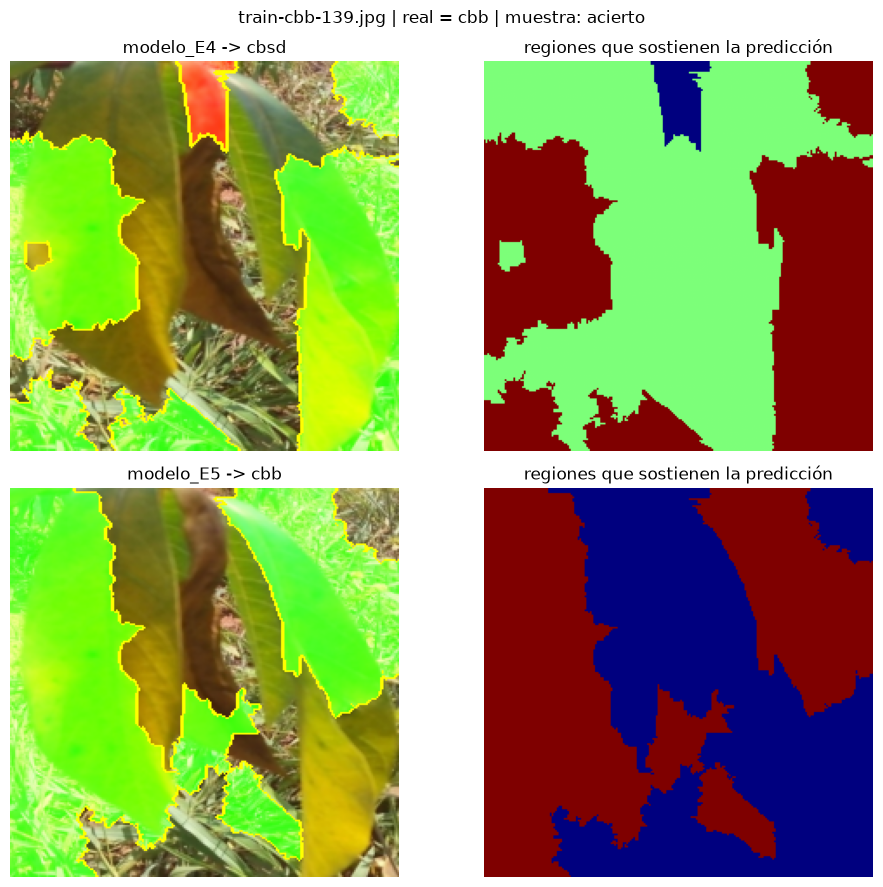

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:22, 21.95it/s]

  4%|▍         | 20/500 [00:00<00:14, 34.00it/s]

  6%|▌         | 30/500 [00:00<00:11, 39.65it/s]

  8%|▊         | 40/500 [00:01<00:10, 44.00it/s]

...

 82%|████████▏ | 411/500 [00:01<00:00, 202.99it/s]

 87%|████████▋ | 436/500 [00:02<00:00, 214.90it/s]

 92%|█████████▏| 458/500 [00:02<00:00, 210.97it/s]

 96%|█████████▌| 480/500 [00:02<00:00, 201.33it/s]

100%|██████████| 500/500 [00:02<00:00, 213.36it/s]

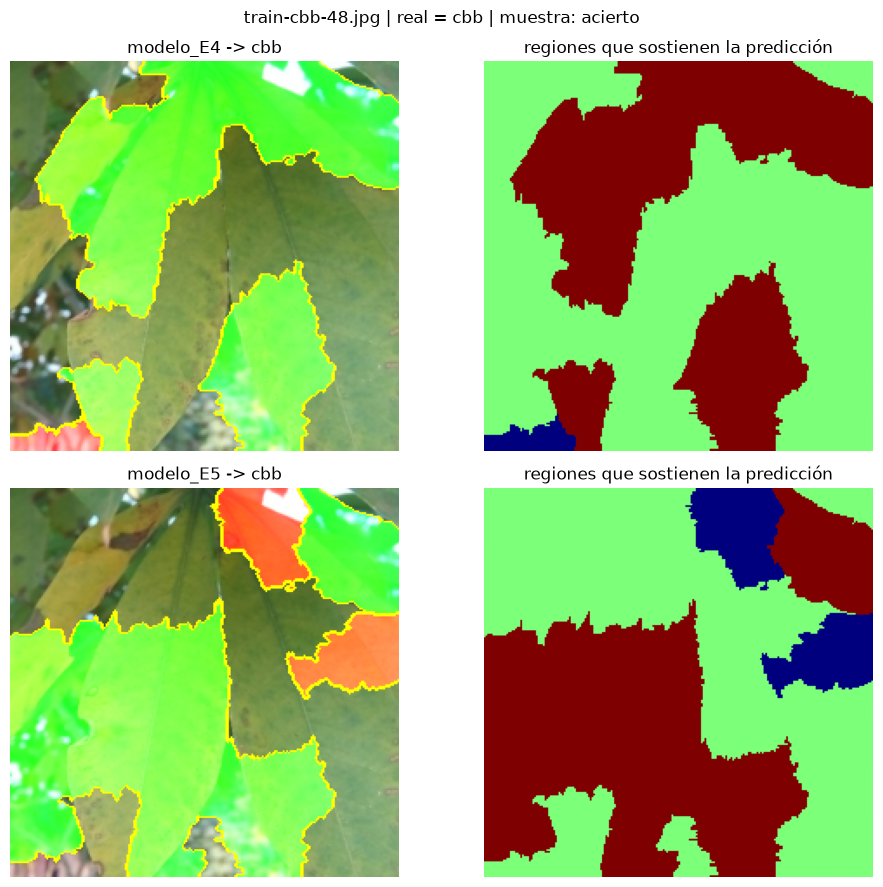

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:17, 28.72it/s]

  4%|▍         | 20/500 [00:00<00:12, 38.01it/s]

  6%|▌         | 30/500 [00:00<00:11, 41.63it/s]

  8%|▊         | 40/500 [00:00<00:10, 44.38it/s]

...

 83%|████████▎ | 417/500 [00:01<00:00, 218.26it/s]

 88%|████████▊ | 440/500 [00:02<00:00, 209.26it/s]

 93%|█████████▎| 467/500 [00:02<00:00, 223.86it/s]

 98%|█████████▊| 490/500 [00:02<00:00, 215.96it/s]

100%|██████████| 500/500 [00:02<00:00, 220.18it/s]

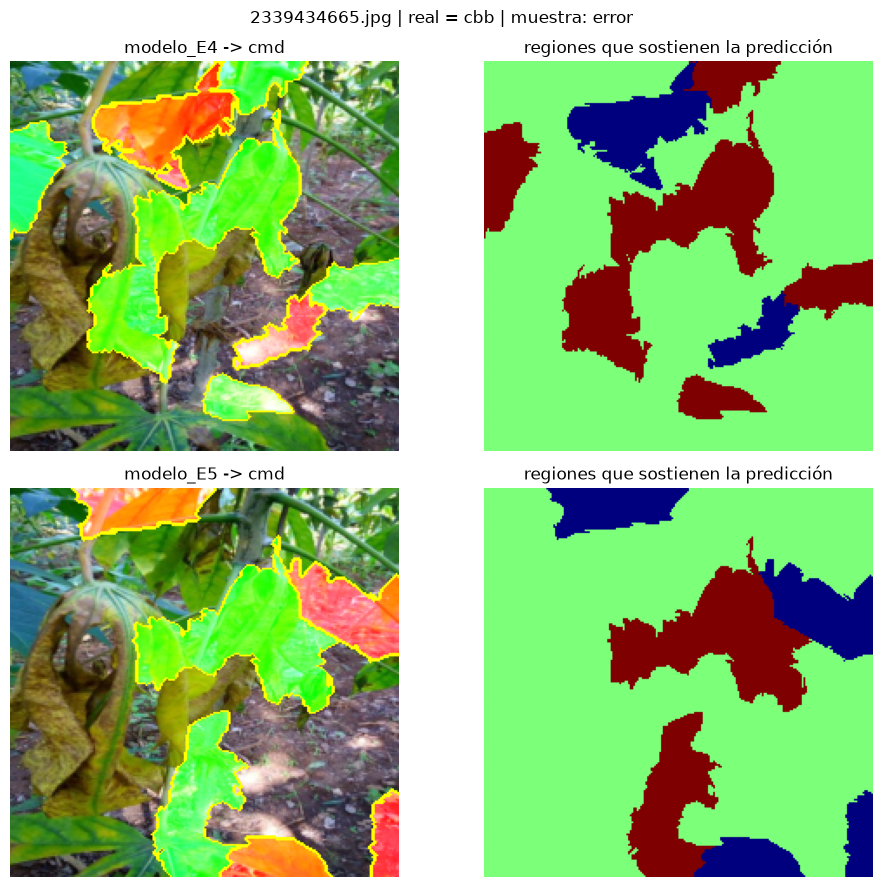

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:15, 32.34it/s]

  4%|▍         | 20/500 [00:00<00:11, 41.41it/s]

  6%|▌         | 30/500 [00:00<00:11, 40.70it/s]

  8%|▊         | 40/500 [00:00<00:11, 41.20it/s]

...

 86%|████████▌ | 430/500 [00:02<00:00, 135.24it/s]

 90%|████████▉ | 449/500 [00:02<00:00, 146.34it/s]

 93%|█████████▎| 465/500 [00:02<00:00, 141.07it/s]

 96%|█████████▌| 480/500 [00:02<00:00, 141.53it/s]

100%|██████████| 500/500 [00:02<00:00, 166.73it/s]

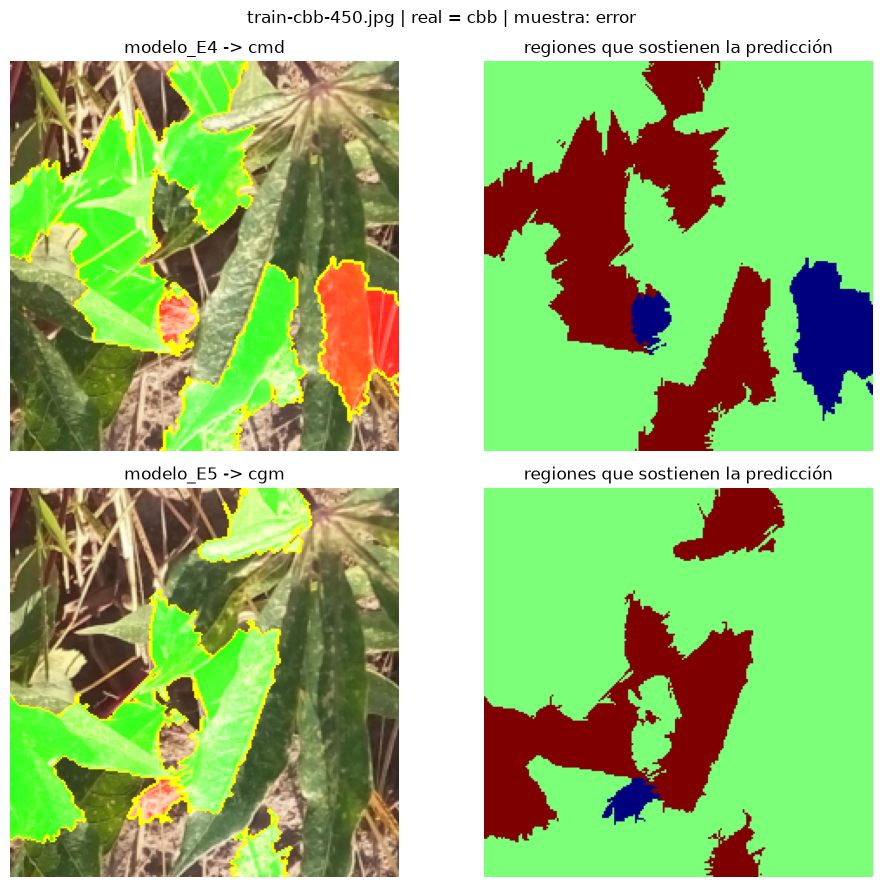

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 35.08it/s]

  4%|▍         | 20/500 [00:00<00:13, 36.44it/s]

  6%|▌         | 30/500 [00:00<00:12, 37.78it/s]

  8%|▊         | 40/500 [00:01<00:13, 35.34it/s]

...

 84%|████████▍ | 419/500 [00:02<00:00, 211.85it/s]

 88%|████████▊ | 441/500 [00:02<00:00, 194.18it/s]

 93%|█████████▎| 464/500 [00:02<00:00, 201.21it/s]

 97%|█████████▋| 485/500 [00:02<00:00, 192.47it/s]

100%|██████████| 500/500 [00:02<00:00, 196.72it/s]

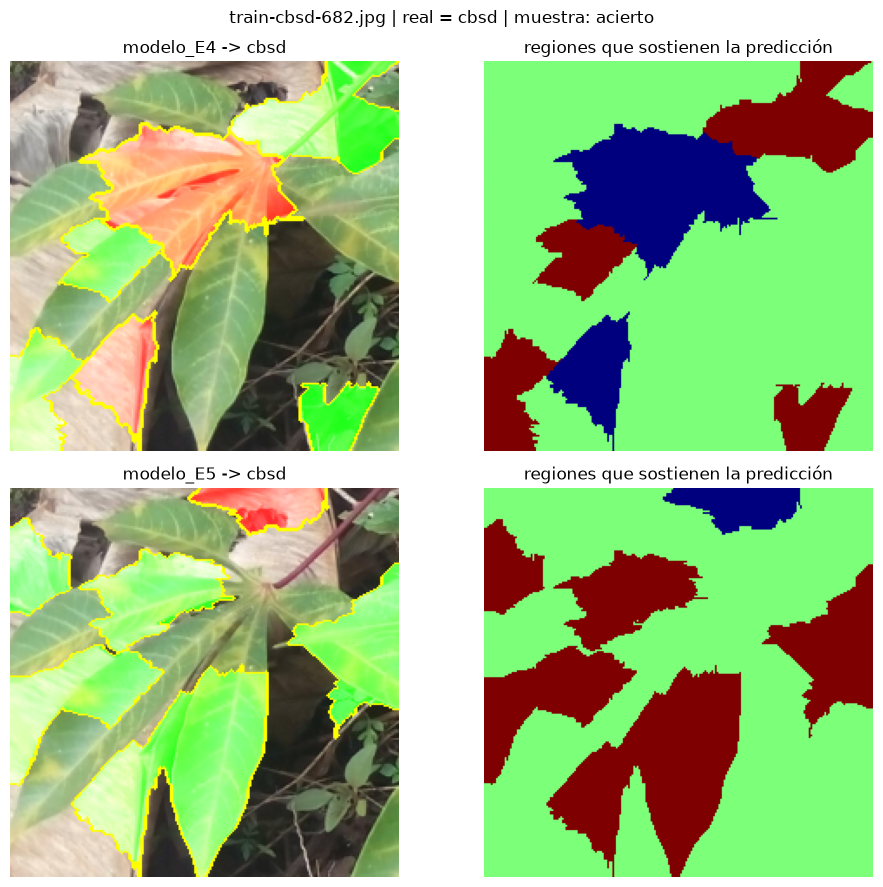

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:14, 33.51it/s]

  4%|▍         | 20/500 [00:00<00:11, 41.54it/s]

  6%|▌         | 30/500 [00:00<00:09, 47.09it/s]

  8%|▊         | 40/500 [00:00<00:09, 47.10it/s]

...

 85%|████████▍ | 424/500 [00:02<00:00, 218.32it/s]

 89%|████████▉ | 446/500 [00:02<00:00, 206.40it/s]

 94%|█████████▎| 468/500 [00:02<00:00, 209.49it/s]

 98%|█████████▊| 490/500 [00:02<00:00, 202.13it/s]

100%|██████████| 500/500 [00:02<00:00, 205.90it/s]

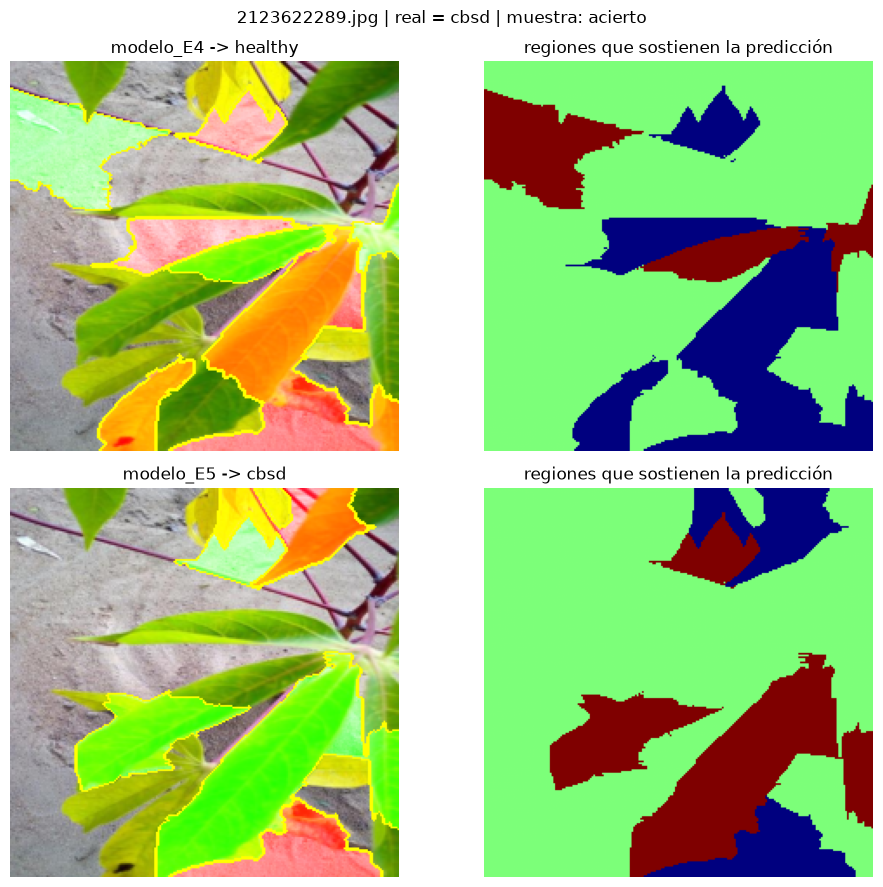

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 36.62it/s]

  4%|▍         | 20/500 [00:00<00:10, 43.90it/s]

  6%|▌         | 30/500 [00:00<00:10, 46.25it/s]

  8%|▊         | 40/500 [00:00<00:09, 47.92it/s]

...

 84%|████████▍ | 419/500 [00:01<00:00, 222.39it/s]

 88%|████████▊ | 442/500 [00:01<00:00, 212.89it/s]

 93%|█████████▎| 467/500 [00:02<00:00, 223.24it/s]

 98%|█████████▊| 490/500 [00:02<00:00, 211.72it/s]

100%|██████████| 500/500 [00:02<00:00, 220.11it/s]

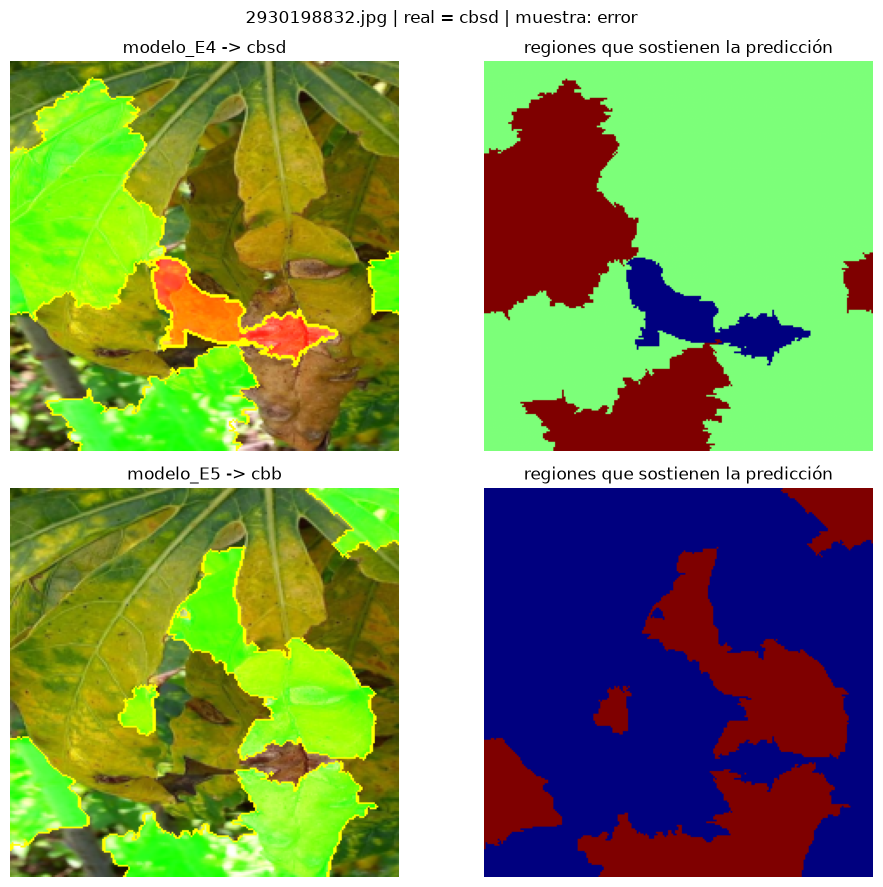

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:14, 34.02it/s]

  4%|▍         | 20/500 [00:00<00:11, 41.15it/s]

  6%|▌         | 30/500 [00:00<00:10, 45.95it/s]

  8%|▊         | 40/500 [00:00<00:09, 47.19it/s]

...

 92%|█████████▏| 460/500 [00:04<00:00, 101.49it/s]

 94%|█████████▍| 471/500 [00:04<00:00, 102.44it/s]

 96%|█████████▋| 482/500 [00:04<00:00, 92.11it/s] 

 99%|█████████▊| 493/500 [00:04<00:00, 96.53it/s]

100%|██████████| 500/500 [00:05<00:00, 99.92it/s]

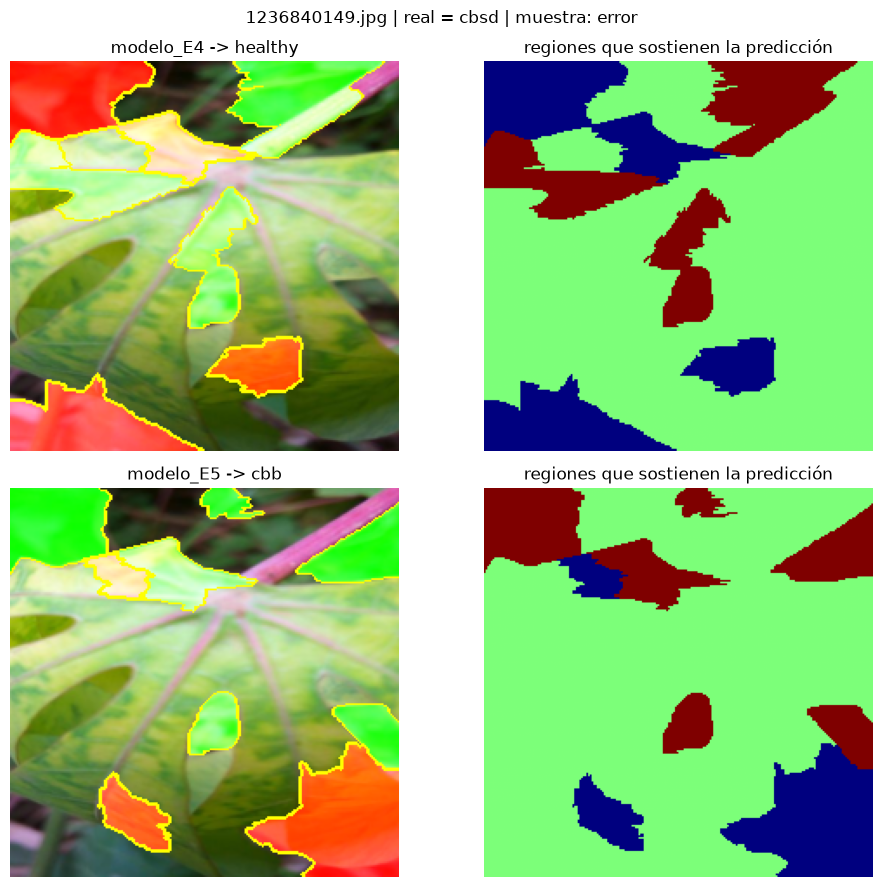

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:35, 13.85it/s]

  4%|▍         | 20/500 [00:01<00:29, 16.10it/s]

  6%|▌         | 30/500 [00:01<00:25, 18.50it/s]

  8%|▊         | 40/500 [00:02<00:23, 19.33it/s]

...

 84%|████████▍ | 420/500 [00:02<00:00, 181.83it/s]

 88%|████████▊ | 440/500 [00:02<00:00, 182.50it/s]

 92%|█████████▏| 461/500 [00:02<00:00, 190.01it/s]

 96%|█████████▌| 481/500 [00:02<00:00, 189.25it/s]

100%|██████████| 500/500 [00:03<00:00, 163.39it/s]

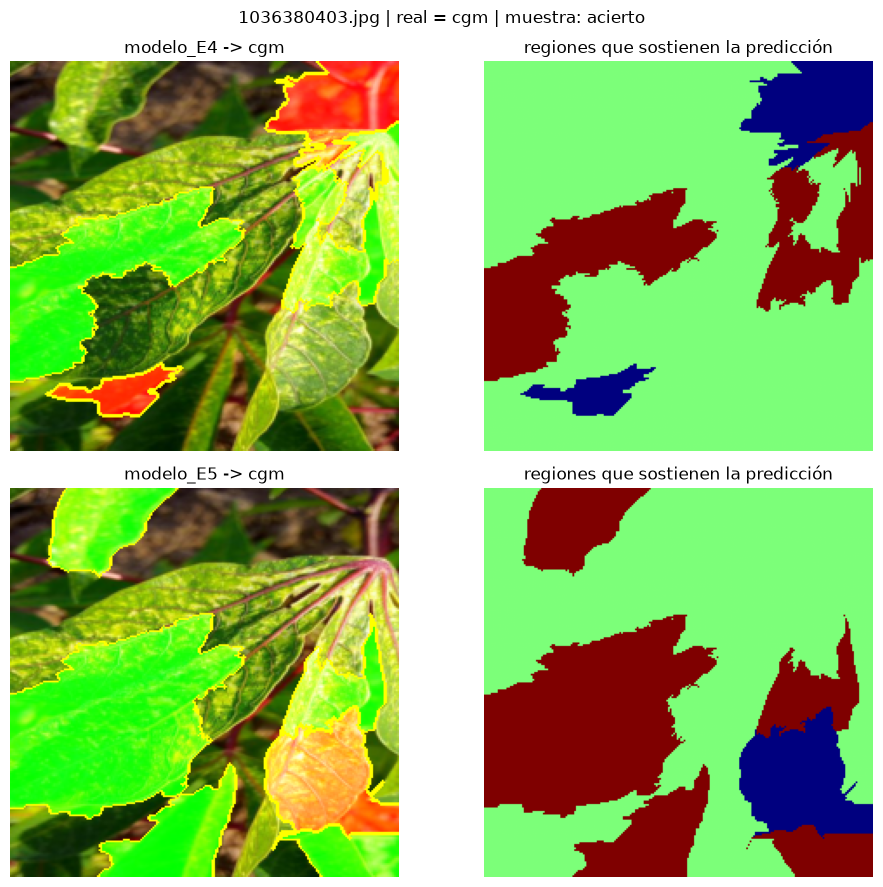

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:22, 22.13it/s]

  4%|▍         | 20/500 [00:00<00:14, 32.16it/s]

  6%|▌         | 30/500 [00:00<00:11, 39.71it/s]

  8%|▊         | 40/500 [00:01<00:10, 44.03it/s]

...

 85%|████████▌ | 426/500 [00:02<00:00, 224.47it/s]

 90%|████████▉ | 449/500 [00:02<00:00, 220.89it/s]

 94%|█████████▍| 472/500 [00:02<00:00, 212.68it/s]

 99%|█████████▉| 496/500 [00:02<00:00, 218.37it/s]

100%|██████████| 500/500 [00:02<00:00, 210.63it/s]

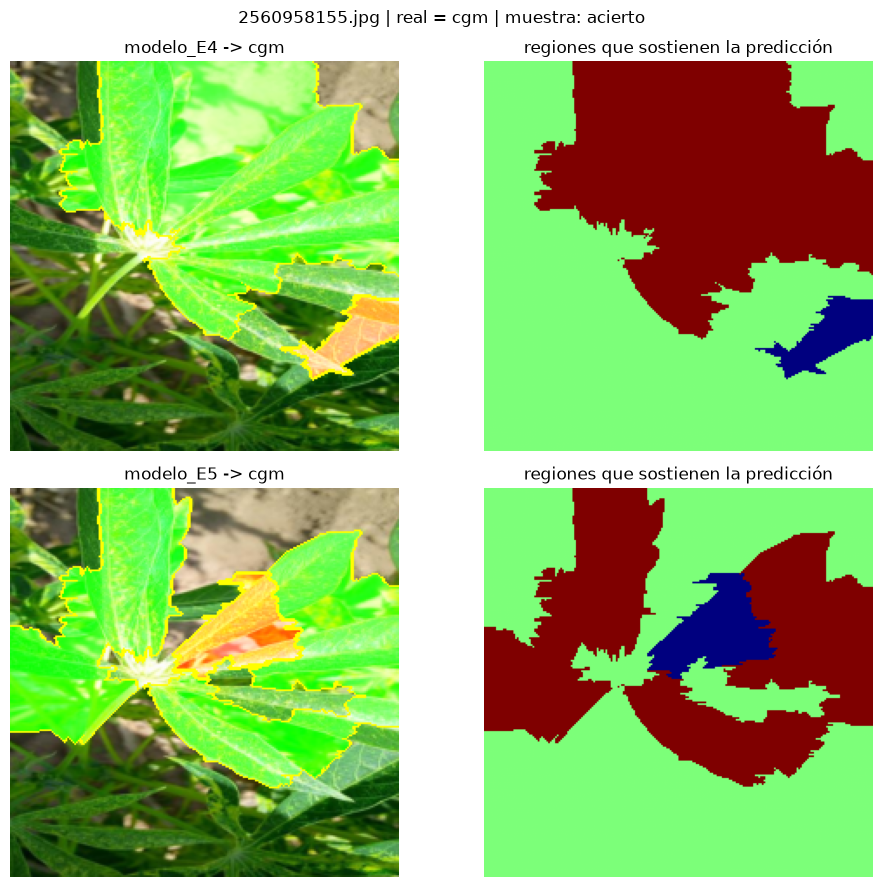

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 36.19it/s]

  4%|▍         | 20/500 [00:00<00:10, 44.08it/s]

  6%|▌         | 30/500 [00:00<00:10, 46.57it/s]

  8%|▊         | 40/500 [00:00<00:09, 48.07it/s]

...

 86%|████████▌ | 430/500 [00:02<00:00, 210.34it/s]

 90%|█████████ | 452/500 [00:02<00:00, 211.25it/s]

 95%|█████████▌| 475/500 [00:02<00:00, 215.75it/s]

100%|█████████▉| 498/500 [00:02<00:00, 219.73it/s]

100%|██████████| 500/500 [00:02<00:00, 211.75it/s]

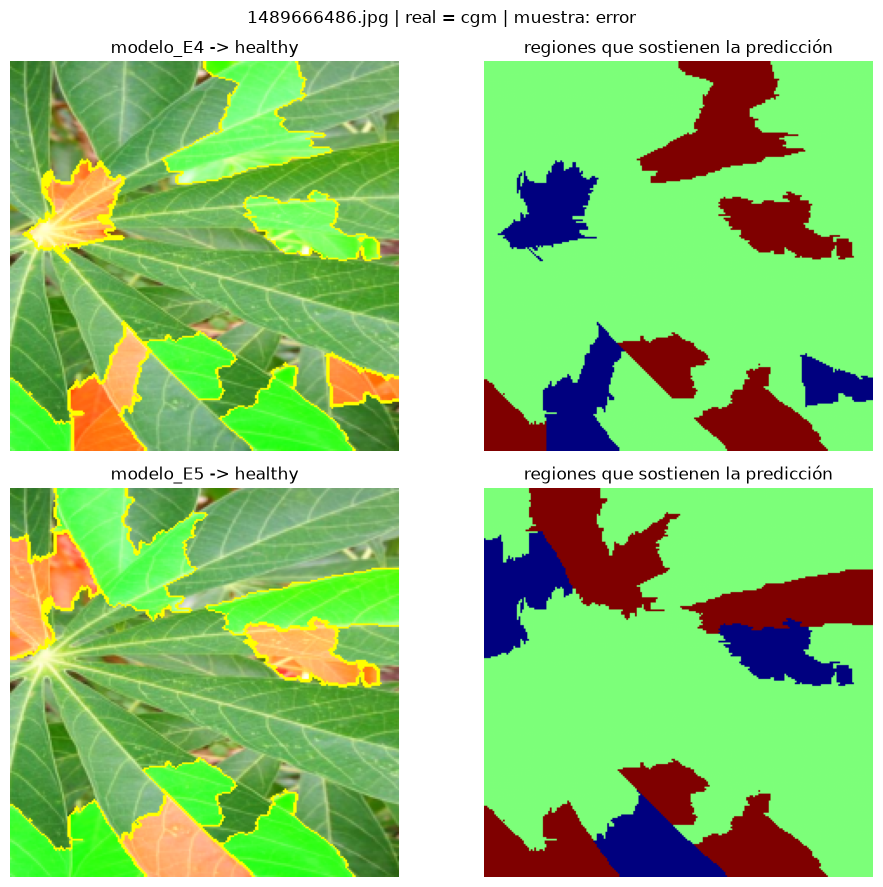

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 35.69it/s]

  4%|▍         | 20/500 [00:00<00:11, 41.51it/s]

  6%|▌         | 30/500 [00:00<00:10, 42.80it/s]

  8%|▊         | 40/500 [00:00<00:10, 45.18it/s]

...

 86%|████████▌ | 429/500 [00:02<00:00, 192.11it/s]

 90%|█████████ | 450/500 [00:02<00:00, 187.94it/s]

 94%|█████████▍| 470/500 [00:02<00:00, 187.99it/s]

 98%|█████████▊| 490/500 [00:02<00:00, 184.53it/s]

100%|██████████| 500/500 [00:02<00:00, 193.71it/s]

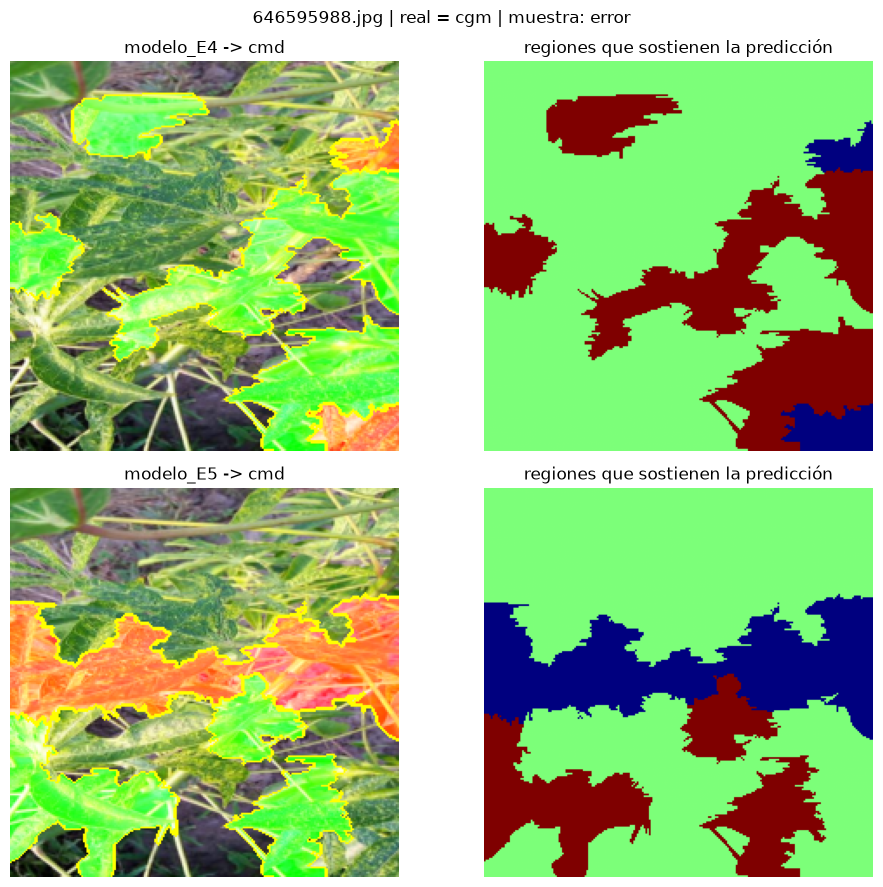

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:18, 27.17it/s]

  4%|▍         | 20/500 [00:00<00:13, 35.94it/s]

  6%|▌         | 30/500 [00:00<00:10, 42.85it/s]

  8%|▊         | 40/500 [00:00<00:10, 44.66it/s]

...

 84%|████████▍ | 420/500 [00:02<00:00, 212.89it/s]

 89%|████████▊ | 443/500 [00:02<00:00, 217.50it/s]

 93%|█████████▎| 465/500 [00:02<00:00, 206.52it/s]

 98%|█████████▊| 490/500 [00:02<00:00, 202.75it/s]

100%|██████████| 500/500 [00:02<00:00, 208.14it/s]

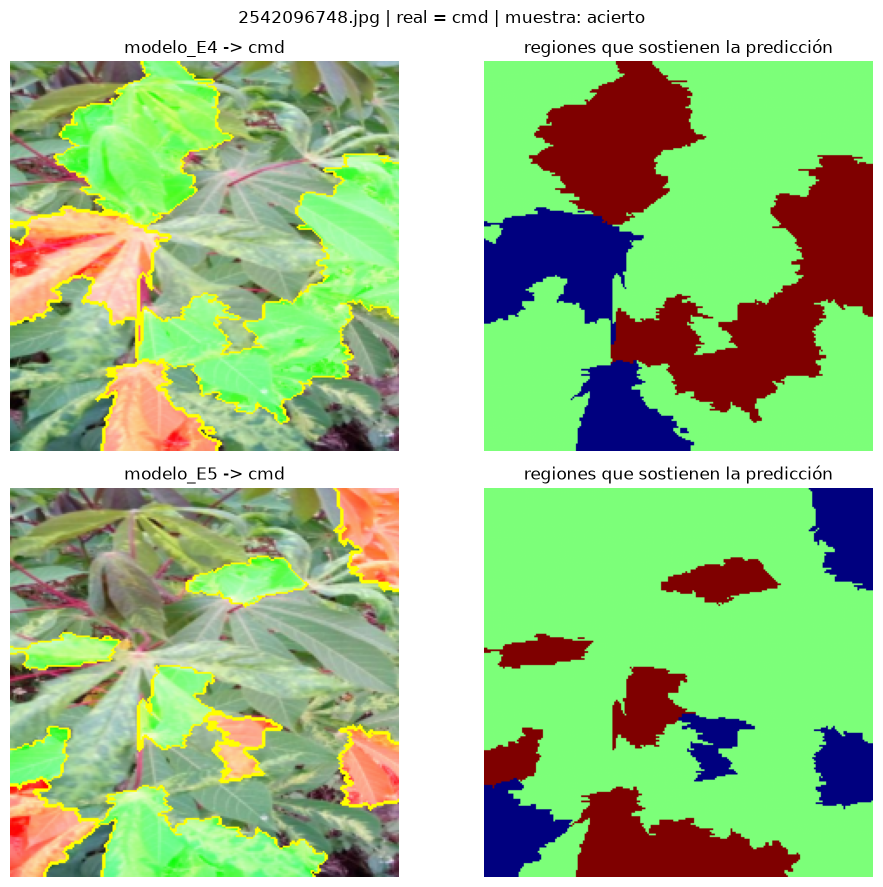

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:14, 34.59it/s]

  4%|▍         | 20/500 [00:00<00:11, 41.19it/s]

  6%|▌         | 30/500 [00:00<00:10, 44.74it/s]

  8%|▊         | 40/500 [00:00<00:09, 47.44it/s]

...

 86%|████████▌ | 431/500 [00:01<00:00, 214.99it/s]

 91%|█████████ | 453/500 [00:02<00:00, 201.80it/s]

 95%|█████████▍| 474/500 [00:02<00:00, 200.71it/s]

 99%|█████████▉| 495/500 [00:02<00:00, 202.32it/s]

100%|██████████| 500/500 [00:02<00:00, 218.47it/s]

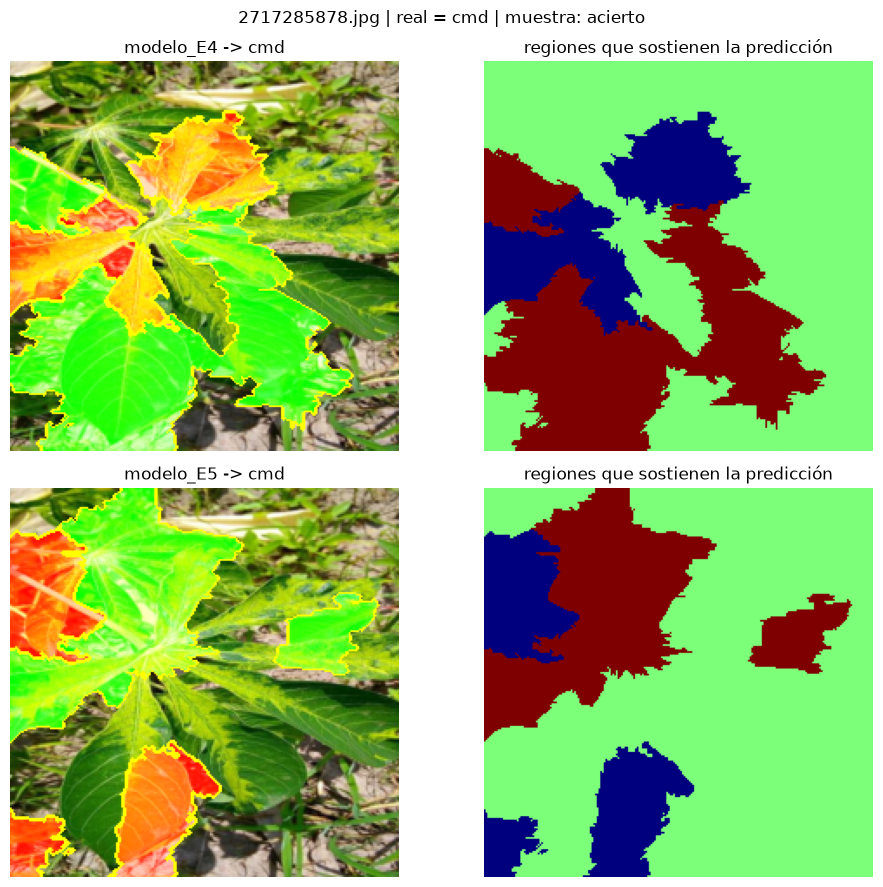

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:14, 34.85it/s]

  4%|▍         | 20/500 [00:00<00:10, 44.28it/s]

  6%|▌         | 30/500 [00:00<00:09, 48.36it/s]

  8%|▊         | 40/500 [00:00<00:08, 51.12it/s]

...

 86%|████████▌ | 430/500 [00:02<00:00, 193.03it/s]

 90%|█████████ | 450/500 [00:02<00:00, 167.94it/s]

 94%|█████████▍| 471/500 [00:02<00:00, 178.33it/s]

 99%|█████████▉| 495/500 [00:02<00:00, 193.90it/s]

100%|██████████| 500/500 [00:02<00:00, 173.04it/s]

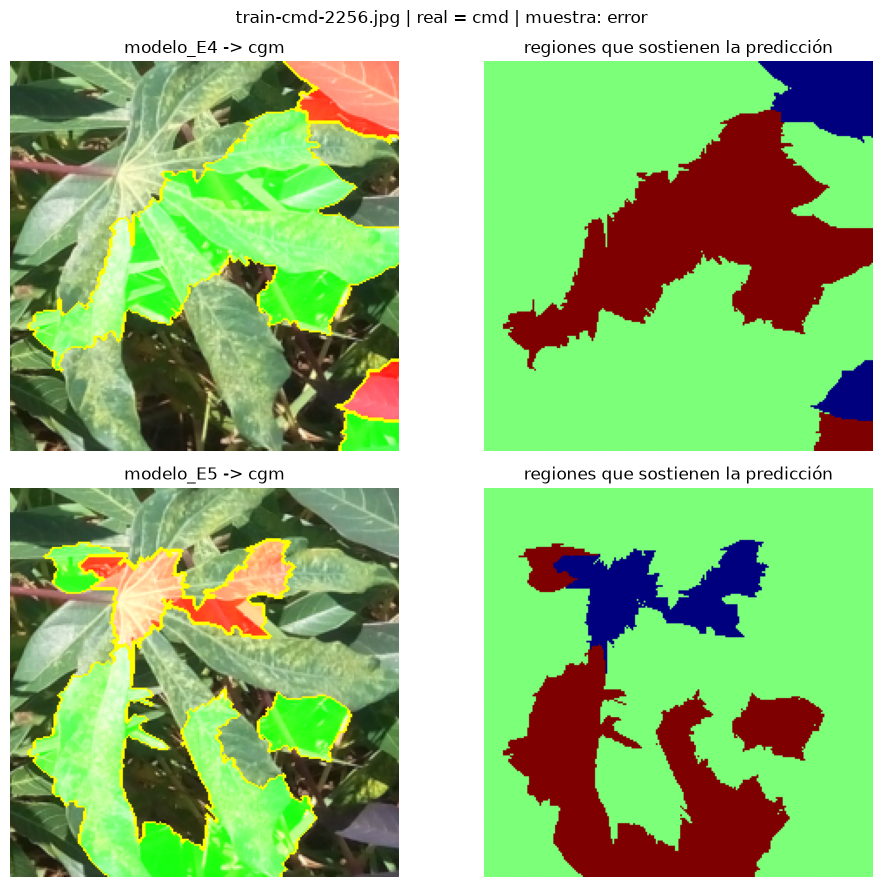

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 35.32it/s]

  4%|▍         | 20/500 [00:00<00:11, 42.95it/s]

  6%|▌         | 30/500 [00:00<00:09, 47.37it/s]

  8%|▊         | 40/500 [00:00<00:09, 50.76it/s]

...

 90%|█████████ | 450/500 [00:02<00:00, 160.93it/s]

 94%|█████████▎| 468/500 [00:03<00:00, 166.06it/s]

 97%|█████████▋| 485/500 [00:03<00:00, 136.33it/s]

100%|██████████| 500/500 [00:03<00:00, 123.26it/s]

100%|██████████| 500/500 [00:03<00:00, 146.13it/s]

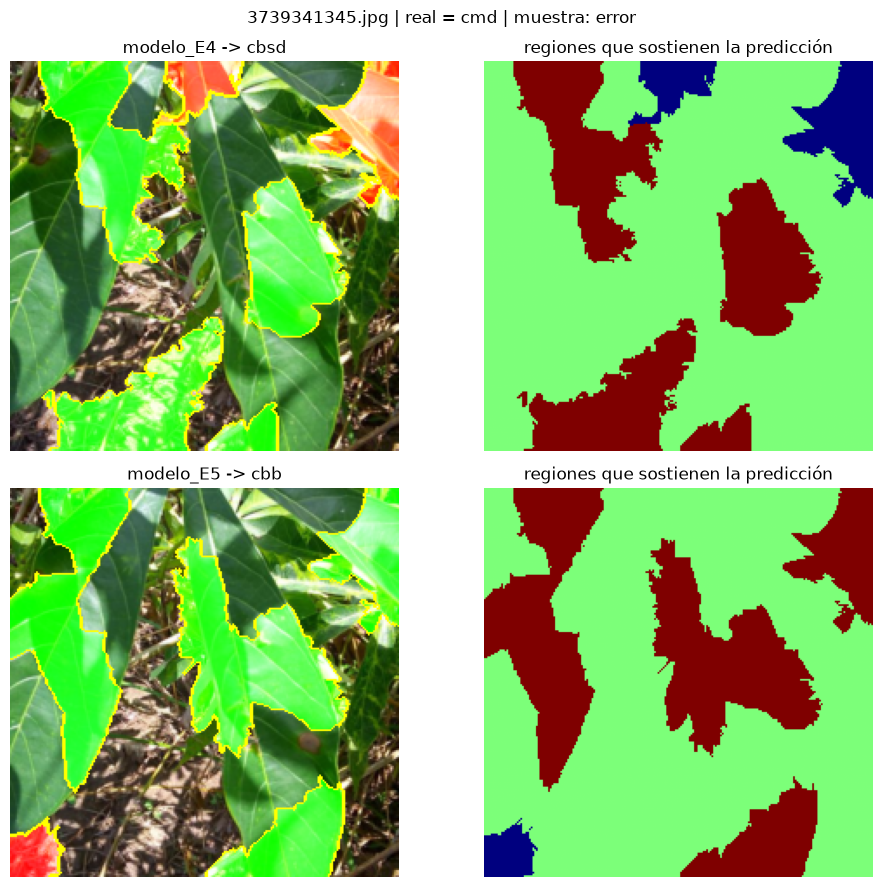

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:16, 30.24it/s]

  4%|▍         | 20/500 [00:00<00:13, 35.97it/s]

  6%|▌         | 30/500 [00:00<00:12, 36.83it/s]

  8%|▊         | 40/500 [00:01<00:11, 38.89it/s]

...

 83%|████████▎ | 414/500 [00:02<00:00, 207.63it/s]

 88%|████████▊ | 438/500 [00:02<00:00, 213.25it/s]

 92%|█████████▏| 460/500 [00:02<00:00, 202.59it/s]

 96%|█████████▌| 481/500 [00:02<00:00, 204.42it/s]

100%|██████████| 500/500 [00:02<00:00, 204.08it/s]

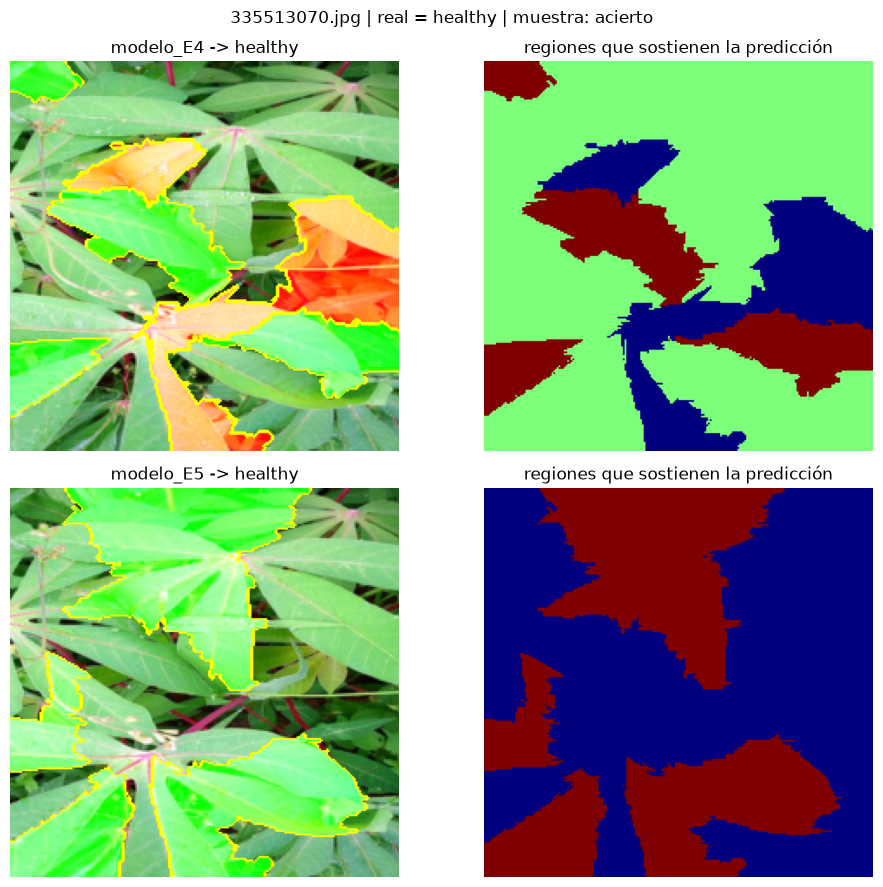

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 36.06it/s]

  4%|▍         | 20/500 [00:00<00:11, 42.55it/s]

  6%|▌         | 30/500 [00:00<00:10, 46.02it/s]

  8%|▊         | 40/500 [00:00<00:09, 48.18it/s]

...

 82%|████████▏ | 410/500 [00:01<00:00, 233.52it/s]

 88%|████████▊ | 438/500 [00:01<00:00, 243.68it/s]

 93%|█████████▎| 463/500 [00:01<00:00, 236.46it/s]

 98%|█████████▊| 490/500 [00:02<00:00, 236.39it/s]

100%|██████████| 500/500 [00:02<00:00, 239.28it/s]

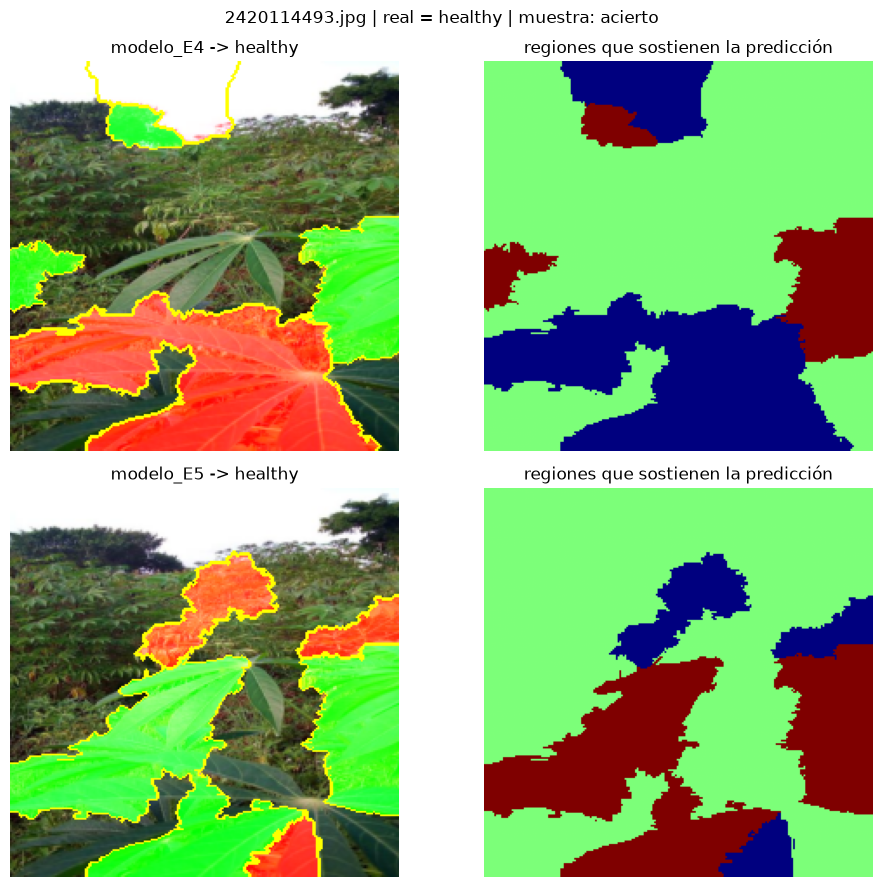

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 36.75it/s]

  4%|▍         | 20/500 [00:00<00:10, 46.01it/s]

  6%|▌         | 30/500 [00:00<00:09, 51.06it/s]

  8%|▊         | 40/500 [00:00<00:08, 51.31it/s]

...

 84%|████████▍ | 419/500 [00:01<00:00, 226.78it/s]

 89%|████████▊ | 443/500 [00:02<00:00, 219.38it/s]

 94%|█████████▍| 470/500 [00:02<00:00, 221.59it/s]

100%|██████████| 500/500 [00:02<00:00, 228.96it/s]

100%|██████████| 500/500 [00:02<00:00, 217.64it/s]

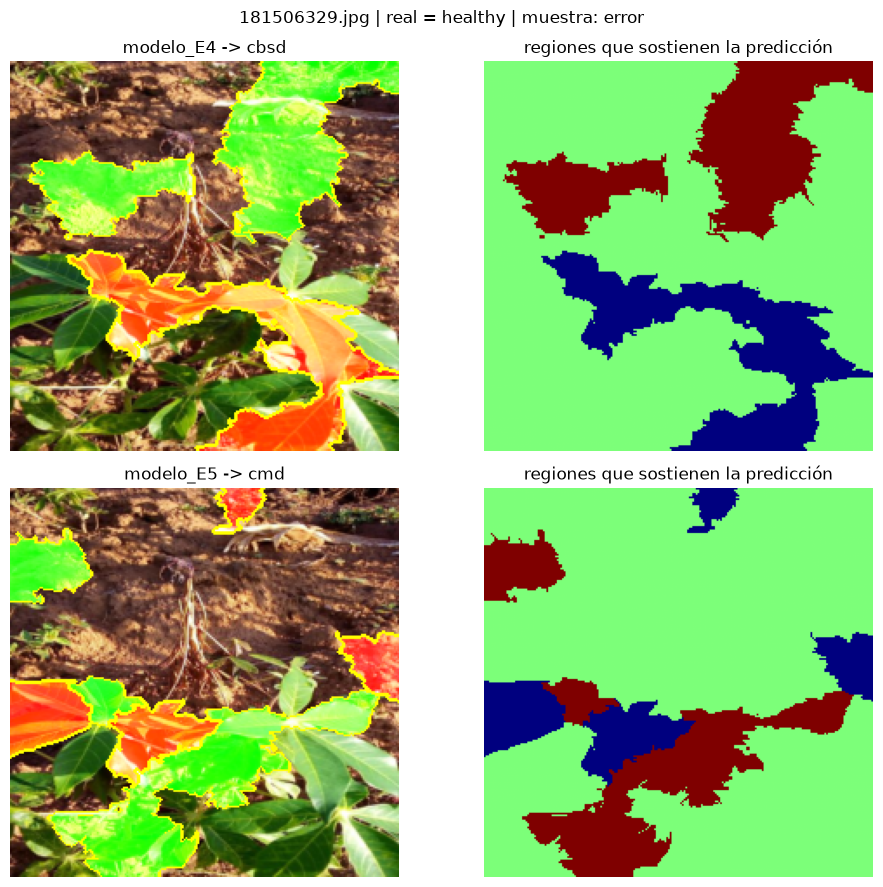

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 10/500 [00:00<00:13, 36.47it/s]

  4%|▍         | 20/500 [00:00<00:10, 44.52it/s]

  6%|▌         | 30/500 [00:00<00:09, 49.45it/s]

  8%|▊         | 40/500 [00:00<00:08, 52.91it/s]

...

 85%|████████▌ | 426/500 [00:02<00:00, 177.70it/s]

 89%|████████▉ | 445/500 [00:02<00:00, 177.38it/s]

 93%|█████████▎| 464/500 [00:02<00:00, 180.07it/s]

 97%|█████████▋| 483/500 [00:02<00:00, 181.33it/s]

100%|██████████| 500/500 [00:02<00:00, 175.24it/s]

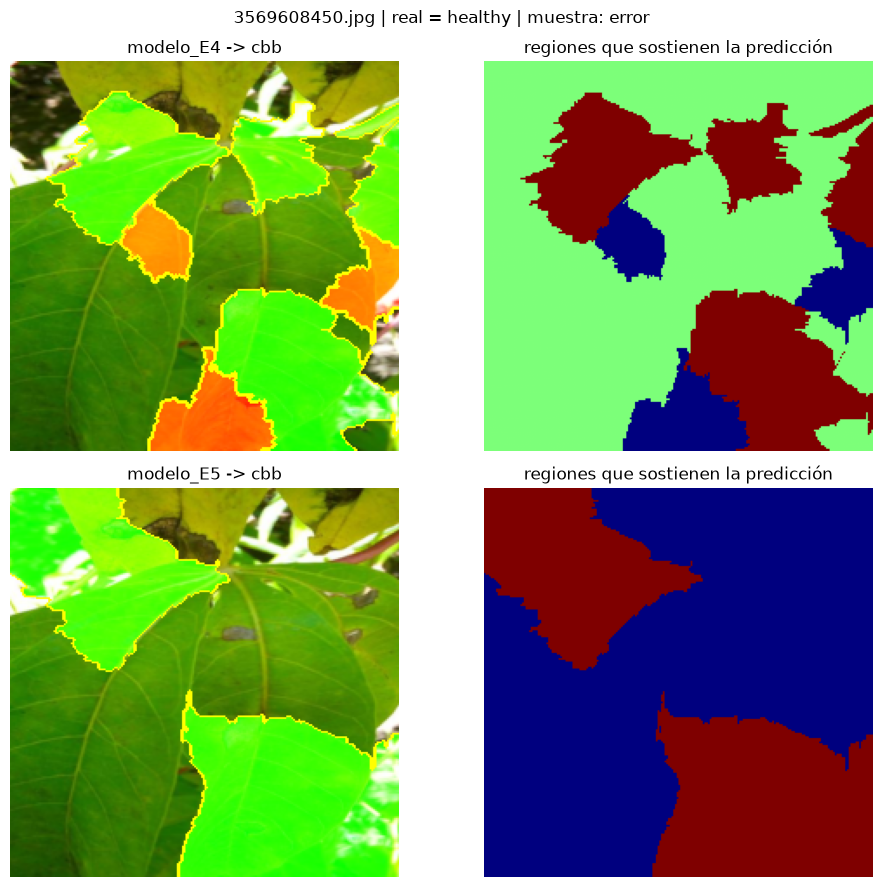

,image_id,clase_real,fuente,tipo,modelo,predicha,acierto
0,train-cbb-139.jpg,cbb,2019,acierto,modelo_E4,cbsd,False
1,train-cbb-139.jpg,cbb,2019,acierto,modelo_E5,cbb,True
2,train-cbb-48.jpg,cbb,2019,acierto,modelo_E4,cbb,True
3,train-cbb-48.jpg,cbb,2019,acierto,modelo_E5,cbb,True
4,2339434665.jpg,cbb,2020,error,modelo_E4,cmd,False
5,2339434665.jpg,cbb,2020,error,modelo_E5,cmd,False
6,train-cbb-450.jpg,cbb,2019,error,modelo_E4,cmd,False
7,train-cbb-450.jpg,cbb,2019,error,modelo_E5,cgm,False
8,train-cbsd-682.jpg,cbsd,2019,acierto,modelo_E4,cbsd,True
9,train-cbsd-682.jpg,cbsd,2019,acierto,modelo_E5,cbsd,True


explicaciones: 40 | % acierto del modelo: {'modelo_E4': 0.45, 'modelo_E5': 0.5}


In [26]:
lime_dir = DIR_REPORT / "lime_antes_despues"
lime_dir.mkdir(parents=True, exist_ok=True)
for viejo in lime_dir.glob("lime_*.png"):
    viejo.unlink()
muestras_lime = []

for i, row in muestra.iterrows():
    img_pil = Image.open(DIR_IMG / row["image_id"]).convert("RGB")
    img = np.asarray(tf_vis(img_pil), dtype=np.float32) / 255.0

    ex = {}
    for etiqueta, fn in [(f"modelo_{M1}", fn_m1), (f"modelo_{M2}", fn_m2)]:
        explanation = explainer.explain_instance(
            img, fn, top_labels=NUM_CLASSES, hide_color=0,
            num_samples=LIME_SAMPLES, random_seed=SEED)
        top = explanation.top_labels[0]
        temp, mask = explanation.get_image_and_mask(
            top, positive_only=False, num_features=10, hide_rest=False)
        ex[etiqueta] = (top, temp, mask)
        muestras_lime.append(dict(image_id=row["image_id"], clase_real=row["label_name"],
                                  fuente=row["source"], tipo=row["tipo"], modelo=etiqueta,
                                  predicha=CLASS_NAMES[top],
                                  acierto=bool(CLASS_NAMES[top] == row["label_name"]),
                                  probs=fn(img[None])[0].round(3).tolist()))

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for r_, (etiqueta, (top, temp, mask)) in zip(range(2), ex.items()):
        axes[r_, 0].imshow(mark_boundaries(temp, mask))
        axes[r_, 0].set_title(f"{etiqueta} -> {CLASS_NAMES[top]}")
        axes[r_, 1].imshow(mask, cmap="jet")
        axes[r_, 1].set_title("regiones que sostienen la predicción")
    for ax in axes.ravel():
        ax.axis("off")
    fig.suptitle(f"{row['image_id']} | real = {row['label_name']} | muestra: {row['tipo']}")
    plt.tight_layout()
    plt.savefig(lime_dir / f"lime_{i:02d}_{row['label_name']}_{row['tipo']}.png", dpi=110)
    plt.show()

df_lime = pd.DataFrame(muestras_lime)
if len(df_lime):
    display(df_lime[["image_id", "clase_real", "fuente", "tipo", "modelo", "predicha", "acierto"]])
    print("explicaciones:", len(df_lime),
          "| % acierto del modelo:", df_lime.groupby("modelo")["acierto"].mean().round(3).to_dict())
else:
    print("sin candidatos para LIME en este modo")


In [27]:
def f1_por_fuente(res):
    te = res["test"]
    y_true = np.array(te["y_true"]); y_pred = np.array(te["y_pred"])
    src = df_test["source"].astype(str).values
    out = {}
    for s in ["2019", "2020"]:
        m = src == s
        if m.sum() > 0:
            out[s] = float(f1_score(y_true[m], y_pred[m], average="macro", zero_division=0))
            out[f"n_{s}"] = int(m.sum())
    return out

tabla_fuente = []
for etiqueta, r in [(f"{mejor_mv2} (antes FT)", RESULTADOS[mejor_mv2]),
                    ("E5 (despues FT)", RESULTADOS["E5"])]:
    tabla_fuente.append(dict(Modelo=etiqueta, **{k: v for k, v in f1_por_fuente(r).items()
                                                 if not k.startswith("n_")},
                             n_2019=f1_por_fuente(r).get("n_2019"),
                             n_2020=f1_por_fuente(r).get("n_2020")))
display(pd.DataFrame(tabla_fuente).round(4))
print("Diferencia 2019-2020 (antes / despues):")

,Modelo,2019,2020,n_2019,n_2020
0,E1 (antes FT),0.6295,0.6114,106,394
1,E5 (despues FT),0.6482,0.6753,106,394


Diferencia 2019-2020 (antes / despues):


## Fase 8 — Reporte global: tabla de todo lo probado

Se ensamblan todos los `*_res.json` (E1-E5 + E6-E9 por backbone) en una única tabla, se guarda en
`reportes\02_resultados_experimentos.csv` y se actualiza **§6 de `reportes\00_resumen_consigna_y_avance.md`**.

In [28]:
filas = []
candidatos = [f for f in sorted(DIR_MODEL.glob("*_res.json"))
              if ("_smoke" in f.name) == SMOKE and "_v2" not in f.name]
for f in candidatos:
    r = json.loads(f.read_text(encoding="utf-8"))
    if r["id"] == "E5":
        ra = json.loads((DIR_MODEL / f"{r['antes']}{TAG}_res.json").read_text(encoding="utf-8"))
        base_a = dict(Backbone=ra["backbone"], Input=ra["size"], Aug="si" if ra["aug"] else "no",
                      Epocas=ra["epochs_run"], Params=ra["params"], s_epoc=ra["tiempo_ep_s"])
        filas.append(dict(ID="E5a", Metodo=f"{r['antes']} (antes FT)", **base_a,
                          F1_val=ra["val"]["f1_macro"], F1_test=ra["test"]["f1_macro"],
                          BalAcc=ra["test"]["balanced_acc"],
                          **{f"f1_{CLASS_NAMES[i]}": ra["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)}))
        base = dict(Backbone=r["backbone"], Input=r["size"], Aug="si" if r["aug"] else "no",
                    Epocas=r["epochs_run"], Params=r["params"], s_epoc=r["tiempo_ep_s"])
        filas.append(dict(ID="E5b", Metodo="MV2 fine-tuning (despues)", **base,
                          F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                          BalAcc=r["test"]["balanced_acc"],
                          **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)}))
    else:
        filas.append(dict(ID=r["id"], Metodo=r["metodo"], Backbone=r["backbone"],
                          Input=r["size"], Aug=("si" if r["aug"] else "no") if r["aug"] is not None else "-",
                          Epocas=r["epochs_run"], Params=r["params"], s_epoc=r["tiempo_ep_s"],
                          F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                          BalAcc=r["test"]["balanced_acc"],
                          **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)}))

df_res = pd.DataFrame(filas)
orden_ids = ["E1", "E2", "E3", "E4", "E5a", "E5b",
             "E6_mobilenetv2", "E7_mobilenetv2", "E8_mobilenetv2", "E9_mobilenetv2",
             "E6_efficientnet", "E7_efficientnet", "E8_efficientnet", "E9_efficientnet"]
df_res["_o"] = pd.Categorical(df_res["ID"], categories=orden_ids, ordered=True)
df_res = df_res.sort_values("_o").drop(columns="_o").reset_index(drop=True)
cols = ["ID", "Metodo", "Backbone", "Input", "Aug", "Epocas", "F1_val", "F1_test",
        "BalAcc", "Params", "s_epoc"] + [f"f1_{c}" for c in CLASS_NAMES]
display(df_res[cols].round(4))

if not SMOKE:
    csv_out = DIR_REPORT / "02_resultados_experimentos.csv"
    df_res.to_csv(csv_out, index=False)
    print("CSV:", csv_out)

,ID,Metodo,Backbone,Input,Aug,Epocas,F1_val,F1_test,BalAcc,Params,s_epoc,f1_cbb,f1_cbsd,f1_cgm,f1_cmd,f1_healthy
0,E1,transfer learning (cabeza),mobilenetv2_100,224.0,no,16.0,0.6152,0.6171,0.622,2230277,65.9,0.5600,0.6294,0.6057,0.7054,0.5849
1,E2,transfer learning (cabeza),mobilenetv2_100,224.0,si,16.0,0.5854,0.5957,0.602,2230277,57.2,0.5882,0.5065,0.6092,0.6953,0.5794
2,E3,transfer learning (cabeza),tf_efficientnet_b7.ra_in1k,600.0,no,7.0,0.6551,0.6529,0.662,63799765,626.9,0.5316,0.6244,0.7188,0.7966,0.5933
3,E4,transfer learning (cabeza),tf_efficientnet_b7.ra_in1k,600.0,si,12.0,0.6455,0.6727,0.680,63799765,650.1,0.5629,0.6422,0.7220,0.8364,0.6000
4,E5a,E1 (antes FT),mobilenetv2_100,224.0,no,16.0,0.6152,0.6171,0.622,2230277,65.9,0.5600,0.6294,0.6057,0.7054,0.5849
5,E5b,MV2 fine-tuning (despues),mobilenetv2_100,224.0,no,6.0,0.6875,0.6706,0.676,1743744,45.3,0.6286,0.7317,0.6550,0.7294,0.6082
6,E6_mobilenetv2,RandomForest,mobilenetv2_100,NaN,-,NaN,0.3537,0.2917,0.340,500,NaN,0.2459,0.4218,0.0583,0.3992,0.3333
7,E7_mobilenetv2,SVM RBF,mobilenetv2_100,NaN,-,NaN,0.6204,0.5622,0.578,2813,NaN,0.3885,0.5882,0.5763,0.6971,0.5607
8,E8_mobilenetv2,XGBoost,mobilenetv2_100,NaN,-,NaN,0.5892,0.5347,0.548,300,NaN,0.4737,0.6042,0.5031,0.6115,0.4809
9,E9_mobilenetv2,MLP (red sobre embeddings),mobilenetv2_100,NaN,-,NaN,0.6502,0.5731,0.580,329221,NaN,0.5366,0.5618,0.5862,0.6667,0.5140


CSV: D:\final_inteligencia\reportes\02_resultados_experimentos.csv


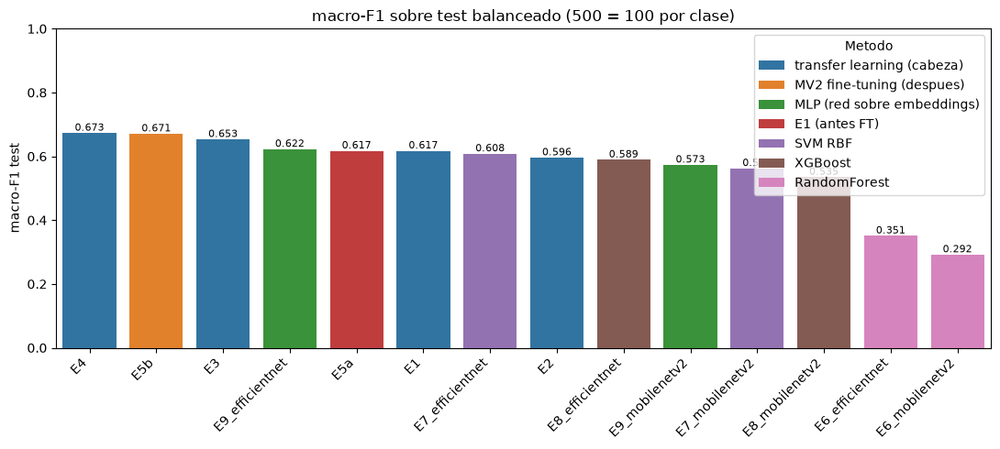

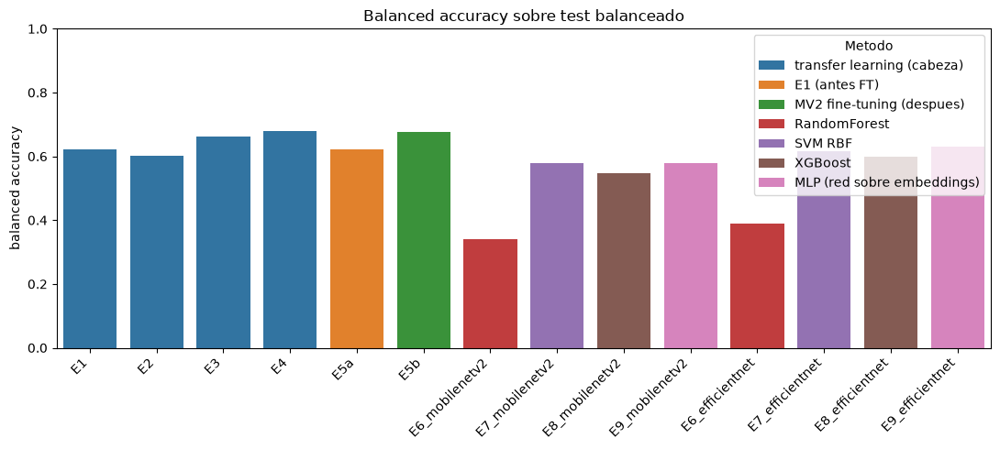

In [29]:
orden_graf = df_res.dropna(subset=["F1_test"]).sort_values("F1_test", ascending=False)
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=orden_graf, x="ID", y="F1_test", hue="Metodo", dodge=False)
ax.set_title("macro-F1 sobre test balanceado (500 = 100 por clase)")
ax.set_ylabel("macro-F1 test"); ax.set_xlabel("")
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=df_res, x="ID", y="BalAcc", hue="Metodo", dodge=False)
plt.title("Balanced accuracy sobre test balanceado")
plt.ylabel("balanced accuracy"); plt.xlabel("")
plt.ylim(0, 1); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

In [30]:
mejor_global = df_res.loc[df_res["F1_test"].idxmax()]
mejor_val = df_res.loc[df_res["F1_val"].idxmax()]
ml_rows = df_res[df_res["Metodo"].str.contains("RandomForest|SVM|XGBoost|MLP")]
mejor_ml = ml_rows.loc[ml_rows["F1_test"].idxmax()] if len(ml_rows) else None
e1 = df_res.set_index("ID").loc["E1"]; e2 = df_res.set_index("ID").loc["E2"]
e3 = df_res.set_index("ID").loc["E3"]; e4 = df_res.set_index("ID").loc["E4"]
ab = df_res.set_index("ID").loc[["E5a", "E5b"]]
delta_ft = float(ab.loc["E5b", "F1_test"] - ab.loc["E5a", "F1_test"])
dif_fuente = pd.DataFrame(tabla_fuente).set_index("Modelo")
idx_antes = [c for c in dif_fuente.index if "antes" in c][0]
idx_desp = [c for c in dif_fuente.index if "despues" in c][0]

def _src(fila, col):
    if col in dif_fuente.columns and pd.notna(dif_fuente.loc[fila, col]):
        return float(dif_fuente.loc[fila, col])
    return float("nan")

n_lime = len(df_lime)
n_muestra = len(muestra)
txt_lat = " · ".join(
    [f"{r.modelo} {r.ms_por_imagen}" for r in
     tabla_latencia_deep[tabla_latencia_deep.batch == 1].itertuples()]
    + [f"{r.backbone}+{r.clasificador} {r.ms_total}" for r in tabla_latencia_clasicos.itertuples()])

tabla_md = chr(10).join(
    "| " + " | ".join([str(r.ID), str(r.Metodo), str(r.Backbone), str(r.Input), str(r.Aug),
                       f"{r.F1_val:.4f}", f"{r.F1_test:.4f}", f"{r.BalAcc:.4f}"]) + " |"
    for r in df_res.itertuples())

txt = f'''### §6 — Resultados de entrenamiento (ítems 1-4 y 6)

**Test: 500 imágenes balanceadas (100 por clase), semilla 42, sin fuga (ver notebook 02).**

| ID | Método | Backbone | Input | Aug | F1-val | F1-test | Balanced acc |
|---|---|---|---|---|---|---|---|
{tabla_md}

- **Mejor modelo global**: `{mejor_global["ID"]}` ({mejor_global["Metodo"]}, {mejor_global["Backbone"]}) →
  **macro-F1 test = {mejor_global["F1_test"]:.4f}** (val {mejor_global["F1_val"]:.4f}).
- **Efecto de la augmentación**: MobileNetV2 {e1["F1_test"]:.4f} → {e2["F1_test"]:.4f} (Δ = {e2["F1_test"] - e1["F1_test"]:+.4f}) ·
  EfficientNet-B7 {e3["F1_test"]:.4f} → {e4["F1_test"]:.4f} (Δ = {e4["F1_test"] - e3["F1_test"]:+.4f}).
- **Fine-tuning MobileNetV2 (E5)**: antes {ab.loc["E5a", "F1_test"]:.4f} → después {ab.loc["E5b", "F1_test"]:.4f}
  (**Δ = {delta_ft:+.4f}**); se descongeló el 30 % de los tensores del backbone (lr 1e-4).
- **Ítem 4 — clasificadores sobre embeddings**: mejor clásico = `{mejor_ml["ID"]}` ({mejor_ml["Metodo"]} sobre {mejor_ml["Backbone"]})
  con macro-F1 test = {mejor_ml["F1_test"]:.4f}.
- **Sesgo de fuente (comprobación cuantitativa)**: macro-F1 2019 vs 2020 =
  {_src(idx_antes, "2019"):.4f} / {_src(idx_antes, "2020"):.4f} (antes del FT) y
  {_src(idx_desp, "2019"):.4f} / {_src(idx_desp, "2020"):.4f} (después del FT).
- **LIME**: {n_lime} explicaciones ({n_muestra} imágenes del test: 2 aciertos + 2 errores por clase, donde
  coinciden {M1} y {M2}) en `reportes/lime_antes_despues/`; se revisa si las regiones resaltadas son
  hoja/síntoma o marco/fondo.
- **Latencia de inferencia (batch=1, ms/imagen)**: {txt_lat}. Tablas completas en
  `reportes/02_latencia_deep.csv` y `reportes/02_latencia_clasicos.csv`.

Pendientes de la consigna: ítem 7 (búsqueda de hiperparámetros) e ítem 8 (robustez con peores fotos).
'''

display(Markdown(txt))

if not SMOKE:
    path_md = DIR_REPORT / "00_resumen_consigna_y_avance.md"
    contenido = path_md.read_text(encoding="utf-8")
    ini, fin = "<!-- INICIO-RESULTADOS-TL -->", "<!-- FIN-RESULTADOS-TL -->"
    bloque = ini + chr(10) + txt + chr(10) + fin
    if ini in contenido:
        ancla = contenido.find("## 6. Resultados de los experimentos de transfer learning")
        if ancla == -1:
            ancla = 0
        i_ini = contenido.index(ini, ancla)
        i_fin = contenido.index(fin, i_ini)
        contenido = contenido[:i_ini] + bloque + contenido[i_fin + len(fin):]
    else:
        contenido = contenido.rstrip() + chr(10) * 2 + "---" + chr(10) * 2 + bloque + chr(10)
    path_md.write_text(contenido, encoding="utf-8")
    print("§6 actualizado en", path_md)

### §6 — Resultados de entrenamiento (ítems 1-4 y 6)

**Test: 500 imágenes balanceadas (100 por clase), semilla 42, sin fuga (ver notebook 02).**

| ID | Método | Backbone | Input | Aug | F1-val | F1-test | Balanced acc |
|---|---|---|---|---|---|---|---|
| E1 | transfer learning (cabeza) | mobilenetv2_100 | 224.0 | no | 0.6152 | 0.6171 | 0.6220 |
| E2 | transfer learning (cabeza) | mobilenetv2_100 | 224.0 | si | 0.5854 | 0.5957 | 0.6020 |
| E3 | transfer learning (cabeza) | tf_efficientnet_b7.ra_in1k | 600.0 | no | 0.6551 | 0.6529 | 0.6620 |
| E4 | transfer learning (cabeza) | tf_efficientnet_b7.ra_in1k | 600.0 | si | 0.6455 | 0.6727 | 0.6800 |
| E5a | E1 (antes FT) | mobilenetv2_100 | 224.0 | no | 0.6152 | 0.6171 | 0.6220 |
| E5b | MV2 fine-tuning (despues) | mobilenetv2_100 | 224.0 | no | 0.6875 | 0.6706 | 0.6760 |
| E6_mobilenetv2 | RandomForest | mobilenetv2_100 | nan | - | 0.3537 | 0.2917 | 0.3400 |
| E7_mobilenetv2 | SVM RBF | mobilenetv2_100 | nan | - | 0.6204 | 0.5622 | 0.5780 |
| E8_mobilenetv2 | XGBoost | mobilenetv2_100 | nan | - | 0.5892 | 0.5347 | 0.5480 |
| E9_mobilenetv2 | MLP (red sobre embeddings) | mobilenetv2_100 | nan | - | 0.6502 | 0.5731 | 0.5800 |
| E6_efficientnet | RandomForest | tf_efficientnet_b7.ra_in1k | nan | - | 0.4434 | 0.3506 | 0.3900 |
| E7_efficientnet | SVM RBF | tf_efficientnet_b7.ra_in1k | nan | - | 0.6370 | 0.6080 | 0.6160 |
| E8_efficientnet | XGBoost | tf_efficientnet_b7.ra_in1k | nan | - | 0.6362 | 0.5890 | 0.6000 |
| E9_efficientnet | MLP (red sobre embeddings) | tf_efficientnet_b7.ra_in1k | nan | - | 0.6693 | 0.6224 | 0.6300 |

- **Mejor modelo global**: `E4` (transfer learning (cabeza), tf_efficientnet_b7.ra_in1k) →
  **macro-F1 test = 0.6727** (val 0.6455).
- **Efecto de la augmentación**: MobileNetV2 0.6171 → 0.5957 (Δ = -0.0214) ·
  EfficientNet-B7 0.6529 → 0.6727 (Δ = +0.0197).
- **Fine-tuning MobileNetV2 (E5)**: antes 0.6171 → después 0.6706
  (**Δ = +0.0535**); se descongeló el 30 % de los tensores del backbone (lr 1e-4).
- **Ítem 4 — clasificadores sobre embeddings**: mejor clásico = `E9_efficientnet` (MLP (red sobre embeddings) sobre tf_efficientnet_b7.ra_in1k)
  con macro-F1 test = 0.6224.
- **Sesgo de fuente (comprobación cuantitativa)**: macro-F1 2019 vs 2020 =
  0.6295 / 0.6114 (antes del FT) y
  0.6482 / 0.6753 (después del FT).
- **LIME**: 40 explicaciones (20 imágenes del test: 2 aciertos + 2 errores por clase, donde
  coinciden E4 y E5) en `reportes/lime_antes_despues/`; se revisa si las regiones resaltadas son
  hoja/síntoma o marco/fondo.
- **Latencia de inferencia (batch=1, ms/imagen)**: E1 20.239 · E2 16.958 · E3 83.022 · E4 73.715 · E5 14.806 · mobilenetv2+RF 144.661 · mobilenetv2+SVM 28.831 · mobilenetv2+XGB 26.372 · mobilenetv2+MLP 25.278 · efficientnet+RF 192.3 · efficientnet+SVM 89.01 · efficientnet+XGB 78.589 · efficientnet+MLP 77.812. Tablas completas en
  `reportes/02_latencia_deep.csv` y `reportes/02_latencia_clasicos.csv`.

Pendientes de la consigna: ítem 7 (búsqueda de hiperparámetros) e ítem 8 (robustez con peores fotos).


§6 actualizado en D:\final_inteligencia\reportes\00_resumen_consigna_y_avance.md


## Reproducibilidad y verificación

- **Semilla 42** en splits, entrenamiento (DataLoader con generator), SVM/RF/XGB y LIME.
- Splits en `datos\splits\manifest_20pct_test100.csv` (test = 100 por clase; `manifest_20pct.csv`
  original queda intacto para v2/v3); checkpoints en `modelos\E1..E5*.pth` (+ embeddings `.npz`);
  si ya existen, las celdas **usan caché** (solo se re-evalúa el test si cambió su tamaño) y no reentrenan.
- Métricas crudas por experimento en `modelos\*_res.json` → tabla consolidada en `reportes\02_resultados_experimentos.csv`.
- Latencia de inferencia en `reportes\02_latencia_deep.csv` y `reportes\02_latencia_clasicos.csv`.
- Ejecución completa:
  `python -m nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=14400 02_transfer_learning_mandioca.ipynb`
  (con el kernel del venv `.venv`; modo rápido de prueba: variable de entorno `SMOKE=1`).
- Exportación de código: `python -m nbconvert --to script 02_transfer_learning_mandioca.ipynb`.